In [21]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from scipy import stats
from scipy.stats import chi2_contingency

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Set paths (notebook is in analysis/ subdirectory, data files are in parent directory)
BASE_DIR = Path("..")  # Parent directory: results/medqa/
RESULTS_DIR = BASE_DIR
SAMPLES_DIR = BASE_DIR
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


## 1. Data Loading & Parsing


In [22]:
def load_results(result_file: str) -> Dict[str, Any]:
    """Load result JSON file and extract metrics."""
    with open(result_file, 'r') as f:
        data = json.load(f)
    return data

def load_samples(samples_file: str) -> List[Dict[str, Any]]:
    """Load sample JSONL file."""
    samples = []
    with open(samples_file, 'r') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line))
    return samples

def extract_json_from_text(text: str) -> Optional[Dict]:
    """Extract JSON object from text, handling incomplete JSON."""
    if not text or not isinstance(text, str):
        return None
    
    text_cleaned = text.strip()
    
    # Try direct parse first
    try:
        return json.loads(text_cleaned)
    except (json.JSONDecodeError, TypeError):
        pass
    
    # Try to find complete JSON object using balanced braces
    start_idx = text_cleaned.find('{')
    if start_idx == -1:
        return None
    
    brace_count = 0
    for i in range(start_idx, len(text_cleaned)):
        if text_cleaned[i] == '{':
            brace_count += 1
        elif text_cleaned[i] == '}':
            brace_count -= 1
            if brace_count == 0:
                json_str = text_cleaned[start_idx:i+1]
                try:
                    return json.loads(json_str)
                except (json.JSONDecodeError, TypeError):
                    return None
    return None

# Load all result files
result_files = {
    'baseline': 'medqa4option_BASELINE.json',
    'L1': 'medqa4options_LEVEL1.json',
    'L2': 'medqa4options_LEVEL2.json',
    'L3': 'medqa4options_LEVEL3.json',
    'L4': 'medqa4options_LEVEL4.json',
    'L5': 'medqa4options_LEVEL5.json',
    'L6': 'medqa4options_LEVEL6.json',
}

sample_files = {
    'baseline': 'samples_BASELINE.jsonl',
    'L1': 'samples_LEVEL1.jsonl',
    'L2': 'samples_LEVEL2.jsonl',
    'L3': 'samples_LEVEL3.jsonl',
    'L4': 'samples_LEVEL4.jsonl',
    'L5': 'samples_LEVEL5.jsonl',
    'L6': 'samples_LEVEL6.jsonl',
}

# Load results
results = {}
for level, filename in result_files.items():
    filepath = RESULTS_DIR / filename
    if filepath.exists():
        results[level] = load_results(str(filepath))
        print(f"✓ Loaded {level}: {filename}")
    else:
        print(f"✗ Warning: {filename} not found")

# Load samples
samples = {}
for level, filename in sample_files.items():
    filepath = SAMPLES_DIR / filename
    if filepath.exists():
        samples[level] = load_samples(str(filepath))
        print(f"✓ Loaded {level} samples: {len(samples[level])} samples")
    else:
        print(f"✗ Warning: {filename} not found")

print(f"\nTotal levels loaded: {len(samples)}")


✓ Loaded baseline: medqa4option_BASELINE.json
✓ Loaded L1: medqa4options_LEVEL1.json
✓ Loaded L2: medqa4options_LEVEL2.json
✓ Loaded L3: medqa4options_LEVEL3.json
✓ Loaded L4: medqa4options_LEVEL4.json
✓ Loaded L5: medqa4options_LEVEL5.json
✓ Loaded L6: medqa4options_LEVEL6.json
✓ Loaded baseline samples: 1273 samples
✓ Loaded L1 samples: 1273 samples
✓ Loaded L2 samples: 1273 samples
✓ Loaded L3 samples: 1273 samples
✓ Loaded L4 samples: 1273 samples
✓ Loaded L5 samples: 1273 samples
✓ Loaded L6 samples: 1273 samples

Total levels loaded: 7


In [23]:
def parse_sample(sample: Dict, level: str) -> Dict[str, Any]:
    """Parse a sample based on schema level with comprehensive extraction."""
    raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
    filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
    target = sample.get('target', '')
    exact_match = sample.get('exact_match', 0)
    doc_id = sample.get('doc_id', -1)
    
    parsed_data = {
        'doc_id': doc_id,
        'raw_response': raw_resp if raw_resp else '',
        'filtered_response': filtered_resp if filtered_resp else '[invalid]',
        'target': target,
        'exact_match': exact_match,
        'json_valid': False,
        'answer': None,
        'confidence': None,
        'reasoning': None,
        'justification': None,
        'eliminated': None,
        'key_evidence': None,
        'key_concepts': None,
        'has_answer': False,
        'has_confidence': False,
        'has_reasoning': False,
        'has_justification': False,
        'has_eliminated': False,
        'has_key_evidence': False,
        'has_key_concepts': False,
        'confidence_valid': False,
        'schema_compliant': False,
    }
    
    # Baseline: extract from free-form text
    if level == 'baseline':
        answer = filtered_resp.strip().upper() if filtered_resp else '[invalid]'
        if answer in ['A', 'B', 'C', 'D']:
            parsed_data['answer'] = answer
            parsed_data['has_answer'] = True
        else:
            parsed_data['answer'] = '[invalid]'
        parsed_data['schema_compliant'] = parsed_data['has_answer']
        return parsed_data
    
    # Schema levels: parse JSON
    if raw_resp and isinstance(raw_resp, str):
        parsed_json = extract_json_from_text(raw_resp)
        if parsed_json and isinstance(parsed_json, dict):
            parsed_data['json_valid'] = True
            parsed_data['answer'] = parsed_json.get('answer', '').strip().upper()
            parsed_data['has_answer'] = parsed_data['answer'] in ['A', 'B', 'C', 'D']
            
            # Extract confidence
            if 'confidence' in parsed_json:
                try:
                    conf = float(parsed_json['confidence'])
                    parsed_data['confidence'] = conf
                    parsed_data['has_confidence'] = True
                    parsed_data['confidence_valid'] = (0.0 <= conf <= 1.0)
                except (ValueError, TypeError):
                    pass
            
            # Extract other fields
            parsed_data['reasoning'] = parsed_json.get('reasoning', '')
            parsed_data['justification'] = parsed_json.get('justification', '')
            parsed_data['has_reasoning'] = bool(parsed_data['reasoning'])
            parsed_data['has_justification'] = bool(parsed_data['justification'])
            
            parsed_data['eliminated'] = parsed_json.get('eliminated', [])
            parsed_data['has_eliminated'] = isinstance(parsed_data['eliminated'], list) and len(parsed_data['eliminated']) > 0
            
            parsed_data['key_evidence'] = parsed_json.get('key_evidence', '')
            parsed_data['has_key_evidence'] = bool(parsed_data['key_evidence'])
            
            parsed_data['key_concepts'] = parsed_json.get('key_concepts', [])
            parsed_data['has_key_concepts'] = isinstance(parsed_data['key_concepts'], list) and len(parsed_data['key_concepts']) > 0
            
            # Check schema compliance based on level
            if level == 'L1':
                parsed_data['schema_compliant'] = parsed_data['json_valid'] and parsed_data['has_answer']
            elif level == 'L2':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_confidence'] and parsed_data['confidence_valid'])
            elif level == 'L3':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_justification'])
            elif level == 'L4':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_reasoning'] and parsed_data['has_confidence'] 
                                                   and parsed_data['confidence_valid'])
            elif level == 'L5':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_eliminated'] and parsed_data['has_key_evidence'])
            elif level == 'L6':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_reasoning'] and parsed_data['has_confidence'] 
                                                   and parsed_data['confidence_valid'] and parsed_data['has_key_concepts'])
        else:
            # Fallback to filtered response
            answer = filtered_resp.strip().upper() if filtered_resp else '[invalid]'
            if answer in ['A', 'B', 'C', 'D']:
                parsed_data['answer'] = answer
                parsed_data['has_answer'] = True
            else:
                parsed_data['answer'] = '[invalid]'
    
    return parsed_data

# Parse all samples
parsed_samples = {}
for level in samples.keys():
    parsed_samples[level] = [parse_sample(s, level) for s in samples[level]]
    print(f"✓ Parsed {len(parsed_samples[level])} samples for {level}")


✓ Parsed 1273 samples for baseline
✓ Parsed 1273 samples for L1
✓ Parsed 1273 samples for L2
✓ Parsed 1273 samples for L3
✓ Parsed 1273 samples for L4
✓ Parsed 1273 samples for L5
✓ Parsed 1273 samples for L6


## 2. Performance Overview


In [24]:
# Extract performance metrics
performance_data = {}

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in results:
        result = results[level]
        exact_match = result['results']['medqa_4options_generation']['exact_match,strict-match']
        exact_match_stderr = result['results']['medqa_4options_generation']['exact_match_stderr,strict-match']
        performance_data[level] = {
            'exact_match': exact_match,
            'stderr': exact_match_stderr,
            'percentage': exact_match * 100
        }

# Create comparison table
print("="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
print(f"{'Level':<12} {'Exact Match':<15} {'Std Error':<15} {'Percentage':<12} {'Improvement':<15}")
print("-"*80)

baseline_score = performance_data.get('baseline', {}).get('exact_match', 0)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in performance_data:
        data = performance_data[level]
        improvement = data['exact_match'] - baseline_score
        improvement_pct = (improvement / baseline_score * 100) if baseline_score > 0 else 0
        improvement_str = f"{improvement:+.4f} ({improvement_pct:+.1f}%)" if level != 'baseline' else "-"
        print(f"{level:<12} {data['exact_match']:<15.4f} {data['stderr']:<15.4f} {data['percentage']:<12.2f}% {improvement_str:<15}")

print("="*80)


PERFORMANCE COMPARISON
Level        Exact Match     Std Error       Percentage   Improvement    
--------------------------------------------------------------------------------
baseline     0.4988          0.0140          49.88       % -              
L1           0.6214          0.0136          62.14       % +0.1225 (+24.6%)
L2           0.6214          0.0136          62.14       % +0.1225 (+24.6%)
L3           0.6127          0.0137          61.27       % +0.1139 (+22.8%)
L4           0.6229          0.0136          62.29       % +0.1241 (+24.9%)
L5           0.5852          0.0138          58.52       % +0.0864 (+17.3%)
L6           0.6229          0.0136          62.29       % +0.1241 (+24.9%)


## 3. Error Analysis: What Types of Errors Are Made?


In [25]:
# Analyze error patterns for each level
error_analysis = {}

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in parsed_samples:
        continue
    
    level_samples = parsed_samples[level]
    total = len(level_samples)
    
    # Categorize errors
    correct = 0
    wrong_answer = 0  # Valid answer but incorrect
    invalid_answer = 0  # Couldn't extract valid answer
    extraction_failure = 0  # Schema-specific: JSON parsing failed
    
    # Track wrong answer patterns
    wrong_answer_patterns = []  # (target, predicted) pairs
    
    for sample in level_samples:
        if sample['exact_match'] == 1.0:
            correct += 1
        elif sample['answer'] == '[invalid]':
            invalid_answer += 1
        elif sample['has_answer'] and sample['answer'] != sample['target']:
            wrong_answer += 1
            wrong_answer_patterns.append((sample['target'], sample['answer']))
        else:
            invalid_answer += 1
    
    # For schema levels, also track JSON failures
    if level != 'baseline':
        json_failures = sum(1 for s in level_samples if not s['json_valid'])
    else:
        json_failures = 0
    
    error_analysis[level] = {
        'total': total,
        'correct': correct,
        'wrong_answer': wrong_answer,
        'invalid_answer': invalid_answer,
        'json_failures': json_failures,
        'wrong_patterns': wrong_answer_patterns,
        'accuracy': correct / total if total > 0 else 0
    }

# Print error analysis
print("="*80)
print("ERROR ANALYSIS BY LEVEL")
print("="*80)
print(f"{'Level':<12} {'Correct':<10} {'Wrong':<10} {'Invalid':<10} {'JSON Fail':<12} {'Accuracy':<10}")
print("-"*80)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in error_analysis:
        continue
    e = error_analysis[level]
    json_fail_str = f"{e['json_failures']}" if level != 'baseline' else "-"
    print(f"{level:<12} {e['correct']:<10} {e['wrong_answer']:<10} {e['invalid_answer']:<10} "
          f"{json_fail_str:<12} {e['accuracy']:<10.4f}")

print("="*80)


ERROR ANALYSIS BY LEVEL
Level        Correct    Wrong      Invalid    JSON Fail    Accuracy  
--------------------------------------------------------------------------------
baseline     635        351        287        -            0.4988    
L1           791        460        22         22           0.6214    
L2           791        460        22         22           0.6214    
L3           780        453        40         76           0.6127    
L4           793        458        22         398          0.6229    
L5           745        427        101        118          0.5852    
L6           793        458        22         418          0.6229    


In [26]:
# Analyze wrong answer patterns: which answers are confused with which?
print("\n" + "="*80)
print("WRONG ANSWER CONFUSION MATRICES")
print("="*80)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in error_analysis:
        continue
    
    patterns = error_analysis[level]['wrong_patterns']
    if not patterns:
        continue
    
    # Build confusion matrix
    confusion = defaultdict(lambda: defaultdict(int))
    for target, predicted in patterns:
        confusion[target][predicted] += 1
    
    print(f"\n{level.upper()} - Wrong Answer Patterns (Target → Predicted):")
    print(f"  Total wrong answers: {len(patterns)}")
    
    # Show most common confusions
    confusion_list = []
    for target in ['A', 'B', 'C', 'D']:
        for predicted in ['A', 'B', 'C', 'D']:
            if target != predicted and confusion[target][predicted] > 0:
                confusion_list.append((target, predicted, confusion[target][predicted]))
    
    confusion_list.sort(key=lambda x: x[2], reverse=True)
    print("  Top confusions:")
    for target, predicted, count in confusion_list[:10]:
        pct = count / len(patterns) * 100
        print(f"    {target} → {predicted}: {count} ({pct:.1f}%)")

print("="*80)



WRONG ANSWER CONFUSION MATRICES

BASELINE - Wrong Answer Patterns (Target → Predicted):
  Total wrong answers: 351
  Top confusions:
    C → D: 40 (11.4%)
    C → A: 35 (10.0%)
    D → A: 35 (10.0%)
    B → A: 34 (9.7%)
    A → D: 32 (9.1%)
    B → D: 32 (9.1%)
    C → B: 31 (8.8%)
    D → B: 29 (8.3%)
    A → B: 27 (7.7%)
    B → C: 26 (7.4%)

L1 - Wrong Answer Patterns (Target → Predicted):
  Total wrong answers: 460
  Top confusions:
    D → A: 49 (10.7%)
    A → C: 42 (9.1%)
    C → A: 41 (8.9%)
    A → D: 40 (8.7%)
    B → C: 40 (8.7%)
    C → B: 40 (8.7%)
    B → A: 38 (8.3%)
    C → D: 37 (8.0%)
    D → B: 36 (7.8%)
    A → B: 34 (7.4%)

L2 - Wrong Answer Patterns (Target → Predicted):
  Total wrong answers: 460
  Top confusions:
    D → A: 49 (10.7%)
    A → C: 42 (9.1%)
    C → A: 41 (8.9%)
    A → D: 40 (8.7%)
    B → C: 40 (8.7%)
    C → B: 40 (8.7%)
    B → A: 38 (8.3%)
    C → D: 37 (8.0%)
    D → B: 36 (7.8%)
    A → B: 34 (7.4%)

L3 - Wrong Answer Patterns (Target → Pre

## 4. Cross-Schema Consistency: Do Schemas Agree?


In [27]:
# Compare answers across schemas for the same questions
# Create a mapping by doc_id
answers_by_doc = defaultdict(dict)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in parsed_samples:
        continue
    for sample in parsed_samples[level]:
        doc_id = sample['doc_id']
        if sample['has_answer']:
            answers_by_doc[doc_id][level] = sample['answer']
        answers_by_doc[doc_id]['target'] = sample['target']

# Analyze agreement
agreement_stats = {
    'total_questions': len(answers_by_doc),
    'all_agree': 0,
    'schemas_agree_but_wrong': 0,
    'schemas_agree_and_correct': 0,
    'disagreement_cases': [],
    'baseline_vs_schema_agreement': defaultdict(int),
}

schema_levels = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']

for doc_id, answers in answers_by_doc.items():
    target = answers.get('target')
    if not target:
        continue
    
    # Get all schema answers (excluding baseline)
    schema_answers = [answers.get(level) for level in schema_levels if level in answers]
    schema_answers = [a for a in schema_answers if a and a != '[invalid]']
    
    if not schema_answers:
        continue
    
    # Check if all schemas agree
    if len(set(schema_answers)) == 1:
        agreement_stats['all_agree'] += 1
        if schema_answers[0] == target:
            agreement_stats['schemas_agree_and_correct'] += 1
        else:
            agreement_stats['schemas_agree_but_wrong'] += 1
    else:
        # Disagreement case
        agreement_stats['disagreement_cases'].append({
            'doc_id': doc_id,
            'target': target,
            'answers': {k: v for k, v in answers.items() if k != 'target'}
        })
    
    # Compare baseline with schemas
    baseline_answer = answers.get('baseline')
    if baseline_answer and baseline_answer != '[invalid]':
        schema_consensus = Counter(schema_answers).most_common(1)[0][0] if schema_answers else None
        if schema_consensus:
            if baseline_answer == schema_consensus:
                agreement_stats['baseline_vs_schema_agreement']['agree'] += 1
            else:
                agreement_stats['baseline_vs_schema_agreement']['disagree'] += 1

print("="*80)
print("CROSS-SCHEMA CONSISTENCY ANALYSIS")
print("="*80)
print(f"Total questions analyzed: {agreement_stats['total_questions']}")
print(f"\nSchema Agreement:")
print(f"  All schemas agree: {agreement_stats['all_agree']} ({agreement_stats['all_agree']/agreement_stats['total_questions']*100:.1f}%)")
print(f"    - Agree and correct: {agreement_stats['schemas_agree_and_correct']} ({agreement_stats['schemas_agree_and_correct']/agreement_stats['total_questions']*100:.1f}%)")
print(f"    - Agree but wrong: {agreement_stats['schemas_agree_but_wrong']} ({agreement_stats['schemas_agree_but_wrong']/agreement_stats['total_questions']*100:.1f}%)")
print(f"  Schemas disagree: {len(agreement_stats['disagreement_cases'])} ({len(agreement_stats['disagreement_cases'])/agreement_stats['total_questions']*100:.1f}%)")

if agreement_stats['baseline_vs_schema_agreement']:
    total_comp = sum(agreement_stats['baseline_vs_schema_agreement'].values())
    agree_pct = agreement_stats['baseline_vs_schema_agreement']['agree'] / total_comp * 100
    print(f"\nBaseline vs Schema Consensus:")
    print(f"  Agree: {agreement_stats['baseline_vs_schema_agreement']['agree']} ({agree_pct:.1f}%)")
    print(f"  Disagree: {agreement_stats['baseline_vs_schema_agreement']['disagree']} ({100-agree_pct:.1f}%)")

print("="*80)


CROSS-SCHEMA CONSISTENCY ANALYSIS
Total questions analyzed: 1273

Schema Agreement:
  All schemas agree: 1237 (97.2%)
    - Agree and correct: 788 (61.9%)
    - Agree but wrong: 449 (35.3%)
  Schemas disagree: 14 (1.1%)

Baseline vs Schema Consensus:
  Agree: 847 (87.3%)
  Disagree: 123 (12.7%)


In [28]:
# Analyze disagreement cases: when schemas disagree, which is more likely correct?
if agreement_stats['disagreement_cases']:
    disagreement_analysis = {
        'total': len(agreement_stats['disagreement_cases']),
        'baseline_correct': 0,
        'schema_majority_correct': 0,
        'both_wrong': 0,
        'level_performance_in_disagreements': defaultdict(lambda: {'correct': 0, 'total': 0})
    }
    
    for case in agreement_stats['disagreement_cases']:
        target = case['target']
        baseline_ans = case['answers'].get('baseline')
        
        # Count schema answers
        schema_answers = [case['answers'].get(level) for level in schema_levels 
                         if level in case['answers'] and case['answers'][level] != '[invalid]']
        if schema_answers:
            schema_majority = Counter(schema_answers).most_common(1)[0][0]
        else:
            schema_majority = None
        
        # Track performance of each level in disagreements
        for level in schema_levels:
            if level in case['answers']:
                ans = case['answers'][level]
                if ans and ans != '[invalid]':
                    disagreement_analysis['level_performance_in_disagreements'][level]['total'] += 1
                    if ans == target:
                        disagreement_analysis['level_performance_in_disagreements'][level]['correct'] += 1
        
        # Analyze correctness
        baseline_correct = (baseline_ans == target) if baseline_ans and baseline_ans != '[invalid]' else False
        schema_correct = (schema_majority == target) if schema_majority else False
        
        if baseline_correct and schema_correct:
            pass  # Both right (shouldn't happen in disagreements, but handle it)
        elif baseline_correct:
            disagreement_analysis['baseline_correct'] += 1
        elif schema_correct:
            disagreement_analysis['schema_majority_correct'] += 1
        else:
            disagreement_analysis['both_wrong'] += 1
    
    print("\n" + "="*80)
    print("DISAGREEMENT CASE ANALYSIS")
    print("="*80)
    print(f"Total disagreement cases: {disagreement_analysis['total']}")
    print(f"  Baseline correct (schemas wrong): {disagreement_analysis['baseline_correct']} ({disagreement_analysis['baseline_correct']/disagreement_analysis['total']*100:.1f}%)")
    print(f"  Schema majority correct (baseline wrong): {disagreement_analysis['schema_majority_correct']} ({disagreement_analysis['schema_majority_correct']/disagreement_analysis['total']*100:.1f}%)")
    print(f"  Both wrong: {disagreement_analysis['both_wrong']} ({disagreement_analysis['both_wrong']/disagreement_analysis['total']*100:.1f}%)")
    
    print(f"\nLevel Performance in Disagreement Cases:")
    for level in schema_levels:
        perf = disagreement_analysis['level_performance_in_disagreements'][level]
        if perf['total'] > 0:
            acc = perf['correct'] / perf['total'] * 100
            print(f"  {level}: {perf['correct']}/{perf['total']} ({acc:.1f}%)")
    
    print("="*80)



DISAGREEMENT CASE ANALYSIS
Total disagreement cases: 14
  Baseline correct (schemas wrong): 2 (14.3%)
  Schema majority correct (baseline wrong): 2 (14.3%)
  Both wrong: 8 (57.1%)

Level Performance in Disagreement Cases:
  L1: 3/14 (21.4%)
  L2: 3/14 (21.4%)
  L3: 4/14 (28.6%)
  L4: 5/14 (35.7%)
  L5: 5/13 (38.5%)
  L6: 5/14 (35.7%)


## 5. Answer Distribution Shifts: Do Schemas Change Answer Selection?


In [29]:
# Compare answer distributions and check for systematic shifts
answer_distributions = {}
answer_by_correctness = defaultdict(lambda: defaultdict(int))

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in parsed_samples:
        continue
    
    level_samples = parsed_samples[level]
    answers = [s['answer'] for s in level_samples]
    answer_counts = Counter(answers)
    
    answer_distributions[level] = {
        'A': answer_counts.get('A', 0),
        'B': answer_counts.get('B', 0),
        'C': answer_counts.get('C', 0),
        'D': answer_counts.get('D', 0),
        '[invalid]': answer_counts.get('[invalid]', 0),
        'total': len(answers)
    }
    
    # Track answer distribution by correctness
    for sample in level_samples:
        if sample['has_answer'] and sample['answer'] != '[invalid]':
            is_correct = sample['exact_match'] == 1.0
            answer_by_correctness[level][(sample['answer'], is_correct)] += 1

# Calculate expected distribution (should be ~25% each if random)
print("="*80)
print("ANSWER DISTRIBUTION ANALYSIS")
print("="*80)
print(f"{'Level':<12} {'A':<8} {'B':<8} {'C':<8} {'D':<8} {'Invalid':<10} {'Total':<8}")
print("-"*80)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in answer_distributions:
        continue
    dist = answer_distributions[level]
    total_valid = dist['total'] - dist['[invalid]']
    print(f"{level:<12} {dist['A']:<8} {dist['B']:<8} {dist['C']:<8} {dist['D']:<8} "
          f"{dist['[invalid]']:<10} {dist['total']:<8}")

print("\n" + "="*80)
print("ANSWER DISTRIBUTION BY CORRECTNESS")
print("="*80)
print(f"{'Level':<12} {'A (✓)':<10} {'A (✗)':<10} {'B (✓)':<10} {'B (✗)':<10} {'C (✓)':<10} {'C (✗)':<10} {'D (✓)':<10} {'D (✗)':<10}")
print("-"*80)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in answer_by_correctness:
        continue
    counts = answer_by_correctness[level]
    row = f"{level:<12}"
    for answer in ['A', 'B', 'C', 'D']:
        correct = counts.get((answer, True), 0)
        wrong = counts.get((answer, False), 0)
        row += f"{correct:<10} {wrong:<10}"
    print(row)

print("="*80)


ANSWER DISTRIBUTION ANALYSIS
Level        A        B        C        D        Invalid    Total   
--------------------------------------------------------------------------------
baseline     292      243      213      238      287        1273    
L1           359      306      334      252      22         1273    
L2           359      306      334      252      22         1273    
L3           354      302      330      247      22         1273    
L4           357      307      335      252      22         1273    
L5           341      289      310      232      24         1273    
L6           357      307      335      252      22         1273    

ANSWER DISTRIBUTION BY CORRECTNESS
Level        A (✓)      A (✗)      B (✓)      B (✗)      C (✓)      C (✗)      D (✓)      D (✗)     
--------------------------------------------------------------------------------
baseline    188        104       156        87        157        56        134        104       
L1          231        

In [30]:
# Test for systematic bias: chi-square test comparing distributions
print("\n" + "="*80)
print("STATISTICAL TEST FOR ANSWER BIAS")
print("="*80)

# Compare baseline vs each schema
baseline_dist = answer_distributions.get('baseline', {})
baseline_counts = [baseline_dist.get('A', 0), baseline_dist.get('B', 0), 
                   baseline_dist.get('C', 0), baseline_dist.get('D', 0)]

for level in ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in answer_distributions:
        continue
    
    schema_dist = answer_distributions[level]
    schema_counts = [schema_dist.get('A', 0), schema_dist.get('B', 0),
                     schema_dist.get('C', 0), schema_dist.get('D', 0)]
    
    # Chi-square test
    contingency = np.array([baseline_counts, schema_counts])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n{level} vs Baseline:")
    print(f"  Chi-square: {chi2:.4f}, p-value: {p_value:.6f}")
    if p_value < 0.05:
        print(f"  → Significant difference in answer distribution (p < 0.05)")
    else:
        print(f"  → No significant difference (p >= 0.05)")

print("="*80)



STATISTICAL TEST FOR ANSWER BIAS

L1 vs Baseline:
  Chi-square: 10.0394, p-value: 0.018234
  → Significant difference in answer distribution (p < 0.05)

L2 vs Baseline:
  Chi-square: 10.0394, p-value: 0.018234
  → Significant difference in answer distribution (p < 0.05)

L3 vs Baseline:
  Chi-square: 10.3489, p-value: 0.015822
  → Significant difference in answer distribution (p < 0.05)

L4 vs Baseline:
  Chi-square: 10.2695, p-value: 0.016409
  → Significant difference in answer distribution (p < 0.05)

L5 vs Baseline:
  Chi-square: 9.8794, p-value: 0.019620
  → Significant difference in answer distribution (p < 0.05)

L6 vs Baseline:
  Chi-square: 10.2695, p-value: 0.016409
  → Significant difference in answer distribution (p < 0.05)


## 6. Confidence Calibration: Is Confidence Predictive?


In [31]:
# Deep confidence analysis for L2, L4, L6
confidence_analysis = {}

for level in ['L2', 'L4', 'L6']:
    if level not in parsed_samples:
        continue
    
    level_samples = parsed_samples[level]
    
    # Extract confidence and correctness
    conf_correct_pairs = [(s['confidence'], s['exact_match'] == 1.0) 
                          for s in level_samples 
                          if s['confidence'] is not None]
    
    if not conf_correct_pairs:
        continue
    
    confidences, correct = zip(*conf_correct_pairs)
    confidences = np.array(confidences)
    correct = np.array(correct)
    
    # Calculate calibration metrics
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(confidences, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    calibration_data = []
    for i in range(n_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_conf = confidences[mask]
            bin_correct = correct[mask]
            mean_conf = np.mean(bin_conf)
            accuracy = np.mean(bin_correct)
            count = np.sum(mask)
            calibration_data.append({
                'bin': i,
                'mean_confidence': mean_conf,
                'accuracy': accuracy,
                'count': count,
                'calibration_error': abs(mean_conf - accuracy)
            })
    
    # Calculate ECE (Expected Calibration Error)
    ece = sum(item['calibration_error'] * item['count'] for item in calibration_data) / len(conf_correct_pairs)
    
    # Correlation between confidence and correctness
    correlation = np.corrcoef(confidences, correct.astype(float))[0, 1]
    
    # High confidence vs low confidence accuracy
    high_conf_threshold = 0.8
    low_conf_threshold = 0.5
    high_conf_mask = confidences >= high_conf_threshold
    low_conf_mask = confidences <= low_conf_threshold
    
    high_conf_accuracy = np.mean(correct[high_conf_mask]) if np.sum(high_conf_mask) > 0 else None
    low_conf_accuracy = np.mean(correct[low_conf_mask]) if np.sum(low_conf_mask) > 0 else None
    
    confidence_analysis[level] = {
        'calibration_data': calibration_data,
        'ece': ece,
        'correlation': correlation,
        'high_conf_accuracy': high_conf_accuracy,
        'low_conf_accuracy': low_conf_accuracy,
        'high_conf_count': np.sum(high_conf_mask),
        'low_conf_count': np.sum(low_conf_mask),
        'mean_confidence_correct': np.mean(confidences[correct]),
        'mean_confidence_incorrect': np.mean(confidences[~correct]),
    }

# Print confidence analysis
print("="*80)
print("CONFIDENCE CALIBRATION ANALYSIS")
print("="*80)

for level in ['L2', 'L4', 'L6']:
    if level not in confidence_analysis:
        continue
    
    data = confidence_analysis[level]
    print(f"\n{level}:")
    print(f"  Expected Calibration Error (ECE): {data['ece']:.4f} (lower is better, 0 = perfect)")
    print(f"  Correlation (confidence ↔ correctness): {data['correlation']:.4f}")
    print(f"  Mean confidence (correct): {data['mean_confidence_correct']:.4f}")
    print(f"  Mean confidence (incorrect): {data['mean_confidence_incorrect']:.4f}")
    print(f"  Difference: {data['mean_confidence_correct'] - data['mean_confidence_incorrect']:+.4f}")
    
    if data['high_conf_accuracy'] is not None:
        print(f"  High confidence (≥{0.8}) accuracy: {data['high_conf_accuracy']:.4f} (n={data['high_conf_count']})")
    if data['low_conf_accuracy'] is not None:
        print(f"  Low confidence (≤{0.5}) accuracy: {data['low_conf_accuracy']:.4f} (n={data['low_conf_count']})")
    
    # Interpretation
    if data['correlation'] > 0.3:
        print(f"  → Strong positive correlation: confidence is predictive")
    elif data['correlation'] > 0.1:
        print(f"  → Moderate correlation: confidence has some predictive value")
    else:
        print(f"  → Weak correlation: confidence is not very predictive")

print("="*80)


CONFIDENCE CALIBRATION ANALYSIS

L2:
  Expected Calibration Error (ECE): 0.3332 (lower is better, 0 = perfect)
  Correlation (confidence ↔ correctness): 0.0055
  Mean confidence (correct): 0.9524
  Mean confidence (incorrect): 0.9511
  Difference: +0.0013
  High confidence (≥0.8) accuracy: 0.6326 (n=1184)
  Low confidence (≤0.5) accuracy: 0.6269 (n=67)
  → Weak correlation: confidence is not very predictive

L4:
  Expected Calibration Error (ECE): 0.2774 (lower is better, 0 = perfect)
  Correlation (confidence ↔ correctness): -0.0286
  Mean confidence (correct): 0.8860
  Mean confidence (incorrect): 0.8940
  Difference: -0.0080
  High confidence (≥0.8) accuracy: 0.6397 (n=791)
  Low confidence (≤0.5) accuracy: 0.6548 (n=84)
  → Weak correlation: confidence is not very predictive

L6:
  Expected Calibration Error (ECE): 0.2498 (lower is better, 0 = perfect)
  Correlation (confidence ↔ correctness): 0.0530
  Mean confidence (correct): 0.8729
  Mean confidence (incorrect): 0.8539
  Differ

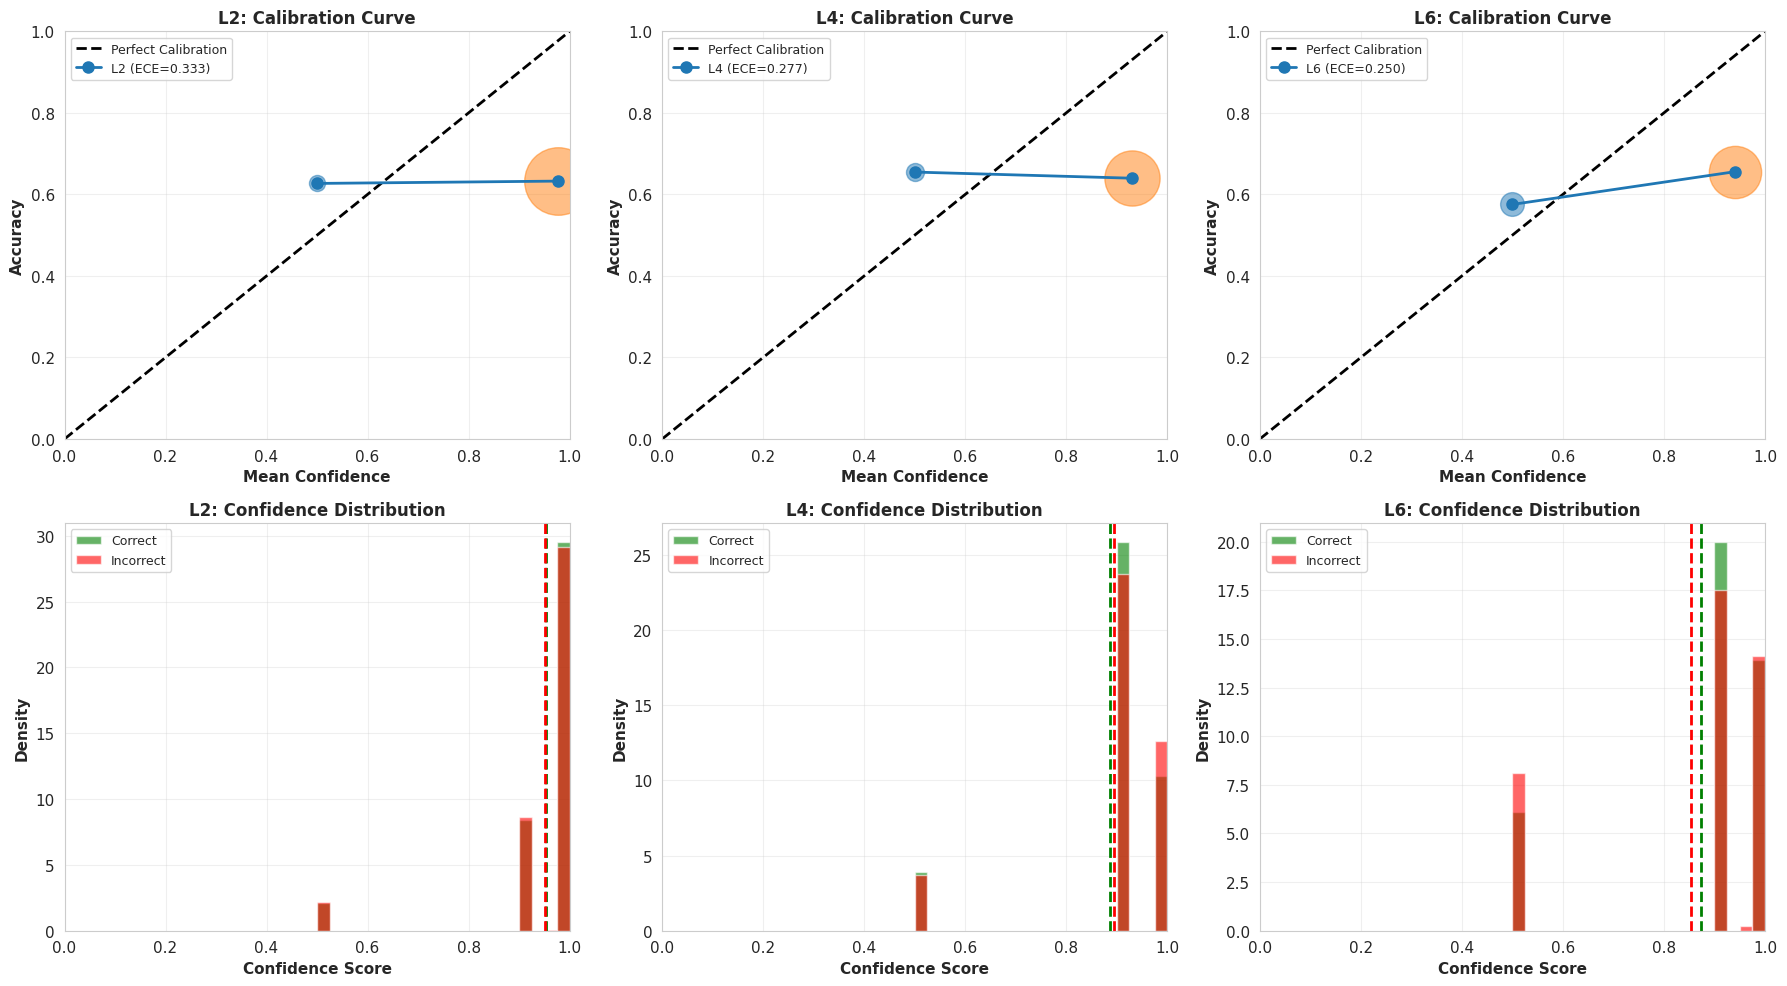

In [32]:
# Visualize confidence calibration
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, level in enumerate(['L2', 'L4', 'L6']):
    if level not in confidence_analysis:
        continue
    
    data = confidence_analysis[level]
    cal_data = data['calibration_data']
    
    # Calibration curve
    ax1 = axes[0, idx]
    mean_confs = [item['mean_confidence'] for item in cal_data]
    accuracies = [item['accuracy'] for item in cal_data]
    counts = [item['count'] for item in cal_data]
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.plot(mean_confs, accuracies, 'o-', label=f'{level} (ECE={data["ece"]:.3f})', 
            linewidth=2, markersize=8)
    
    # Size points by count
    for i, (x, y, count) in enumerate(zip(mean_confs, accuracies, counts)):
        ax1.scatter(x, y, s=count*2, alpha=0.5)
    
    ax1.set_xlabel('Mean Confidence', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax1.set_title(f'{level}: Calibration Curve', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # Confidence distribution by correctness
    ax2 = axes[1, idx]
    level_samples = parsed_samples[level]
    correct_conf = [s['confidence'] for s in level_samples 
                   if s['confidence'] is not None and s['exact_match'] == 1.0]
    incorrect_conf = [s['confidence'] for s in level_samples 
                     if s['confidence'] is not None and s['exact_match'] == 0]
    
    if correct_conf and incorrect_conf:
        ax2.hist(correct_conf, bins=20, alpha=0.6, label='Correct', color='green', density=True)
        ax2.hist(incorrect_conf, bins=20, alpha=0.6, label='Incorrect', color='red', density=True)
        ax2.axvline(np.mean(correct_conf), color='green', linestyle='--', linewidth=2)
        ax2.axvline(np.mean(incorrect_conf), color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax2.set_title(f'{level}: Confidence Distribution', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(alpha=0.3)
        ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confidence_calibration.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Reasoning Quality Analysis (L3, L4, L6)


In [33]:
# Analyze reasoning quality and its correlation with correctness
reasoning_analysis = {}

for level in ['L3', 'L4', 'L6']:
    if level not in parsed_samples:
        continue
    
    level_samples = parsed_samples[level]
    
    reasoning_lengths_correct = []
    reasoning_lengths_incorrect = []
    has_reasoning_correct = 0
    has_reasoning_incorrect = 0
    
    for sample in level_samples:
        if sample['has_reasoning'] or sample['has_justification']:
            reasoning_text = sample.get('reasoning', '') or sample.get('justification', '')
            reasoning_len = len(reasoning_text)
            
            if sample['exact_match'] == 1.0:
                reasoning_lengths_correct.append(reasoning_len)
                has_reasoning_correct += 1
            else:
                reasoning_lengths_incorrect.append(reasoning_len)
                has_reasoning_incorrect += 1
    
    reasoning_analysis[level] = {
        'has_reasoning_correct': has_reasoning_correct,
        'has_reasoning_incorrect': has_reasoning_incorrect,
        'mean_length_correct': np.mean(reasoning_lengths_correct) if reasoning_lengths_correct else None,
        'mean_length_incorrect': np.mean(reasoning_lengths_incorrect) if reasoning_lengths_incorrect else None,
        'reasoning_lengths_correct': reasoning_lengths_correct,
        'reasoning_lengths_incorrect': reasoning_lengths_incorrect,
    }

print("="*80)
print("REASONING QUALITY ANALYSIS")
print("="*80)

for level in ['L3', 'L4', 'L6']:
    if level not in reasoning_analysis:
        continue
    
    data = reasoning_analysis[level]
    total_with_reasoning = data['has_reasoning_correct'] + data['has_reasoning_incorrect']
    
    print(f"\n{level}:")
    print(f"  Samples with reasoning:")
    print(f"    Correct answers: {data['has_reasoning_correct']}")
    print(f"    Incorrect answers: {data['has_reasoning_incorrect']}")
    
    if data['mean_length_correct'] is not None:
        print(f"  Reasoning length (correct): {data['mean_length_correct']:.1f} chars")
    if data['mean_length_incorrect'] is not None:
        print(f"  Reasoning length (incorrect): {data['mean_length_incorrect']:.1f} chars")
    
    if data['mean_length_correct'] and data['mean_length_incorrect']:
        diff = data['mean_length_correct'] - data['mean_length_incorrect']
        print(f"  Length difference: {diff:+.1f} chars")
        if diff > 20:
            print(f"    → Correct answers have longer reasoning")
        elif diff < -20:
            print(f"    → Incorrect answers have longer reasoning")
        else:
            print(f"    → No significant length difference")

print("="*80)


REASONING QUALITY ANALYSIS

L3:
  Samples with reasoning:
    Correct answers: 761
    Incorrect answers: 436
  Reasoning length (correct): 199.6 chars
  Reasoning length (incorrect): 199.7 chars
  Length difference: -0.0 chars
    → No significant length difference

L4:
  Samples with reasoning:
    Correct answers: 561
    Incorrect answers: 314
  Reasoning length (correct): 199.7 chars
  Reasoning length (incorrect): 199.6 chars
  Length difference: +0.1 chars
    → No significant length difference

L6:
  Samples with reasoning:
    Correct answers: 549
    Incorrect answers: 306
  Reasoning length (correct): 489.2 chars
  Reasoning length (incorrect): 487.6 chars
  Length difference: +1.6 chars
    → No significant length difference


## 8. L5 Deep Dive: Elimination Strategy Analysis


In [34]:
# Deep analysis of L5: are eliminated options actually wrong?
if 'L5' in parsed_samples:
    l5_samples = parsed_samples['L5']
    
    l5_elimination_analysis = {
        'total': len(l5_samples),
        'has_eliminated': 0,
        'correct_eliminations': 0,  # Eliminated option was actually wrong
        'incorrect_eliminations': 0,  # Eliminated option was actually correct
        'elimination_count_dist': Counter(),
        'elimination_accuracy': [],  # For each sample, what % of eliminated options were actually wrong
    }
    
    for sample in l5_samples:
        target = sample['target']
        eliminated = sample.get('eliminated', [])
        
        if eliminated and isinstance(eliminated, list):
            l5_elimination_analysis['has_eliminated'] += 1
            l5_elimination_analysis['elimination_count_dist'][len(eliminated)] += 1
            
            # Check if eliminated options are actually wrong
            correct_elim = 0
            total_elim = 0
            
            for elim_item in eliminated:
                if isinstance(elim_item, dict):
                    elim_option = elim_item.get('option', '').strip().upper()
                    if elim_option in ['A', 'B', 'C', 'D']:
                        total_elim += 1
                        if elim_option != target:  # Correctly eliminated (it's not the answer)
                            correct_elim += 1
                        else:  # Incorrectly eliminated (it was the answer!)
                            l5_elimination_analysis['incorrect_eliminations'] += 1
            
            if total_elim > 0:
                acc = correct_elim / total_elim
                l5_elimination_analysis['elimination_accuracy'].append(acc)
                l5_elimination_analysis['correct_eliminations'] += correct_elim
    
    # Print L5 elimination analysis
    print("="*80)
    print("L5 ELIMINATION STRATEGY ANALYSIS")
    print("="*80)
    print(f"Total samples: {l5_elimination_analysis['total']}")
    print(f"Samples with eliminated array: {l5_elimination_analysis['has_eliminated']}")
    print(f"\nElimination count distribution:")
    for count, freq in sorted(l5_elimination_analysis['elimination_count_dist'].items()):
        print(f"  {count} eliminated: {freq} samples ({freq/l5_elimination_analysis['total']*100:.1f}%)")
    
    if l5_elimination_analysis['elimination_accuracy']:
        mean_acc = np.mean(l5_elimination_analysis['elimination_accuracy'])
        print(f"\nElimination accuracy:")
        print(f"  Mean: {mean_acc:.4f} ({mean_acc*100:.1f}%)")
        print(f"  → This means on average, {mean_acc*100:.1f}% of eliminated options were actually wrong")
        print(f"  → Expected: 100% (all eliminated options should be wrong)")
        print(f"  → Gap: {100 - mean_acc*100:.1f} percentage points")
    
    print(f"\nElimination errors:")
    print(f"  Total correct eliminations: {l5_elimination_analysis['correct_eliminations']}")
    print(f"  Total incorrect eliminations: {l5_elimination_analysis['incorrect_eliminations']}")
    if l5_elimination_analysis['correct_eliminations'] + l5_elimination_analysis['incorrect_eliminations'] > 0:
        error_rate = l5_elimination_analysis['incorrect_eliminations'] / (
            l5_elimination_analysis['correct_eliminations'] + l5_elimination_analysis['incorrect_eliminations']
        ) * 100
        print(f"  Error rate: {error_rate:.2f}%")
    
    print("="*80)


L5 ELIMINATION STRATEGY ANALYSIS
Total samples: 1273
Samples with eliminated array: 958

Elimination count distribution:
  1 eliminated: 4 samples (0.3%)
  2 eliminated: 2 samples (0.2%)
  3 eliminated: 942 samples (74.0%)
  4 eliminated: 10 samples (0.8%)

Elimination accuracy:
  Mean: 0.8782 (87.8%)
  → This means on average, 87.8% of eliminated options were actually wrong
  → Expected: 100% (all eliminated options should be wrong)
  → Gap: 12.2 percentage points

Elimination errors:
  Total correct eliminations: 2522
  Total incorrect eliminations: 352
  Error rate: 12.25%


## 9. Answer Quality Shifts: Do Schemas Change Which Answers Are Selected?


In [35]:
# Compare answers for the same questions across baseline and schemas
# This tells us if schemas change the model's answer selection, not just extraction

answer_changes = {
    'baseline_to_schema': defaultdict(int),  # How often does answer change from baseline to schema?
    'schema_to_baseline': defaultdict(int),  # Reverse direction
    'same_answer': 0,
    'different_answer': 0,
    'baseline_correct_schema_wrong': 0,
    'baseline_wrong_schema_correct': 0,
    'both_correct': 0,
    'both_wrong': 0,
}

for doc_id, answers in answers_by_doc.items():
    target = answers.get('target')
    baseline_ans = answers.get('baseline')
    
    if not target or not baseline_ans or baseline_ans == '[invalid]':
        continue
    
    # Compare with each schema
    for level in schema_levels:
        schema_ans = answers.get(level)
        if not schema_ans or schema_ans == '[invalid]':
            continue
        
        baseline_correct = (baseline_ans == target)
        schema_correct = (schema_ans == target)
        
        if baseline_ans == schema_ans:
            answer_changes['same_answer'] += 1
            if baseline_correct:
                answer_changes['both_correct'] += 1
            else:
                answer_changes['both_wrong'] += 1
        else:
            answer_changes['different_answer'] += 1
            answer_changes['baseline_to_schema'][(baseline_ans, schema_ans)] += 1
            
            if baseline_correct and not schema_correct:
                answer_changes['baseline_correct_schema_wrong'] += 1
            elif not baseline_correct and schema_correct:
                answer_changes['baseline_wrong_schema_correct'] += 1

total_comparisons = answer_changes['same_answer'] + answer_changes['different_answer']

print("="*80)
print("ANSWER SELECTION CHANGES: Baseline vs Schemas")
print("="*80)
print(f"Total comparisons: {total_comparisons}")
print(f"  Same answer: {answer_changes['same_answer']} ({answer_changes['same_answer']/total_comparisons*100:.1f}%)")
print(f"  Different answer: {answer_changes['different_answer']} ({answer_changes['different_answer']/total_comparisons*100:.1f}%)")

print(f"\nWhen answers differ:")
print(f"  Baseline correct → Schema wrong: {answer_changes['baseline_correct_schema_wrong']} ({answer_changes['baseline_correct_schema_wrong']/answer_changes['different_answer']*100:.1f}%)")
print(f"  Baseline wrong → Schema correct: {answer_changes['baseline_wrong_schema_correct']} ({answer_changes['baseline_wrong_schema_correct']/answer_changes['different_answer']*100:.1f}%)")

print(f"\nMost common answer changes:")
changes_sorted = sorted(answer_changes['baseline_to_schema'].items(), key=lambda x: x[1], reverse=True)
for (baseline, schema), count in changes_sorted[:10]:
    pct = count / answer_changes['different_answer'] * 100
    print(f"  {baseline} → {schema}: {count} ({pct:.1f}%)")

print("="*80)


ANSWER SELECTION CHANGES: Baseline vs Schemas
Total comparisons: 5741
  Same answer: 5008 (87.2%)
  Different answer: 733 (12.8%)

When answers differ:
  Baseline correct → Schema wrong: 221 (30.2%)
  Baseline wrong → Schema correct: 321 (43.8%)

Most common answer changes:
  D → C: 144 (19.6%)
  D → B: 107 (14.6%)
  D → A: 89 (12.1%)
  A → C: 73 (10.0%)
  B → A: 68 (9.3%)
  A → B: 52 (7.1%)
  B → C: 52 (7.1%)
  B → D: 48 (6.5%)
  A → D: 41 (5.6%)
  C → D: 24 (3.3%)


## 10. Performance by Answer Type: Are Some Answers Easier?


In [36]:
# Analyze performance by target answer (A, B, C, D)
# This tells us if certain answer types are harder/easier

performance_by_target = defaultdict(lambda: defaultdict(lambda: {'correct': 0, 'total': 0}))

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in parsed_samples:
        continue
    
    for sample in parsed_samples[level]:
        target = sample['target']
        if target in ['A', 'B', 'C', 'D']:
            performance_by_target[level][target]['total'] += 1
            if sample['exact_match'] == 1.0:
                performance_by_target[level][target]['correct'] += 1

print("="*80)
print("PERFORMANCE BY TARGET ANSWER TYPE")
print("="*80)

for level in ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level not in performance_by_target:
        continue
    
    print(f"\n{level.upper()}:")
    print(f"{'Target':<8} {'Correct':<10} {'Total':<10} {'Accuracy':<10}")
    print("-"*40)
    
    for target in ['A', 'B', 'C', 'D']:
        perf = performance_by_target[level][target]
        if perf['total'] > 0:
            acc = perf['correct'] / perf['total'] * 100
            print(f"{target:<8} {perf['correct']:<10} {perf['total']:<10} {acc:<10.2f}%")

print("="*80)

# Check if there's systematic bias in difficulty
print("\n" + "="*80)
print("DIFFICULTY ANALYSIS: Which answers are hardest?")
print("="*80)

# Aggregate across all levels
target_difficulty = defaultdict(lambda: {'correct': 0, 'total': 0})
for level in performance_by_target.values():
    for target, perf in level.items():
        target_difficulty[target]['correct'] += perf['correct']
        target_difficulty[target]['total'] += perf['total']

print(f"{'Target':<8} {'Overall Accuracy':<20} {'Total Questions':<20}")
print("-"*50)
for target in ['A', 'B', 'C', 'D']:
    diff = target_difficulty[target]
    if diff['total'] > 0:
        acc = diff['correct'] / diff['total'] * 100
        print(f"{target:<8} {acc:<20.2f}% {diff['total']:<20}")

print("="*80)


PERFORMANCE BY TARGET ANSWER TYPE

BASELINE:
Target   Correct    Total      Accuracy  
----------------------------------------
A        188        353        53.26     %
B        156        309        50.49     %
C        157        346        45.38     %
D        134        265        50.57     %

L1:
Target   Correct    Total      Accuracy  
----------------------------------------
A        231        353        65.44     %
B        196        309        63.43     %
C        219        346        63.29     %
D        145        265        54.72     %

L2:
Target   Correct    Total      Accuracy  
----------------------------------------
A        231        353        65.44     %
B        196        309        63.43     %
C        219        346        63.29     %
D        145        265        54.72     %

L3:
Target   Correct    Total      Accuracy  
----------------------------------------
A        228        353        64.59     %
B        194        309        62.78     %
C     

## 11. Visualizations


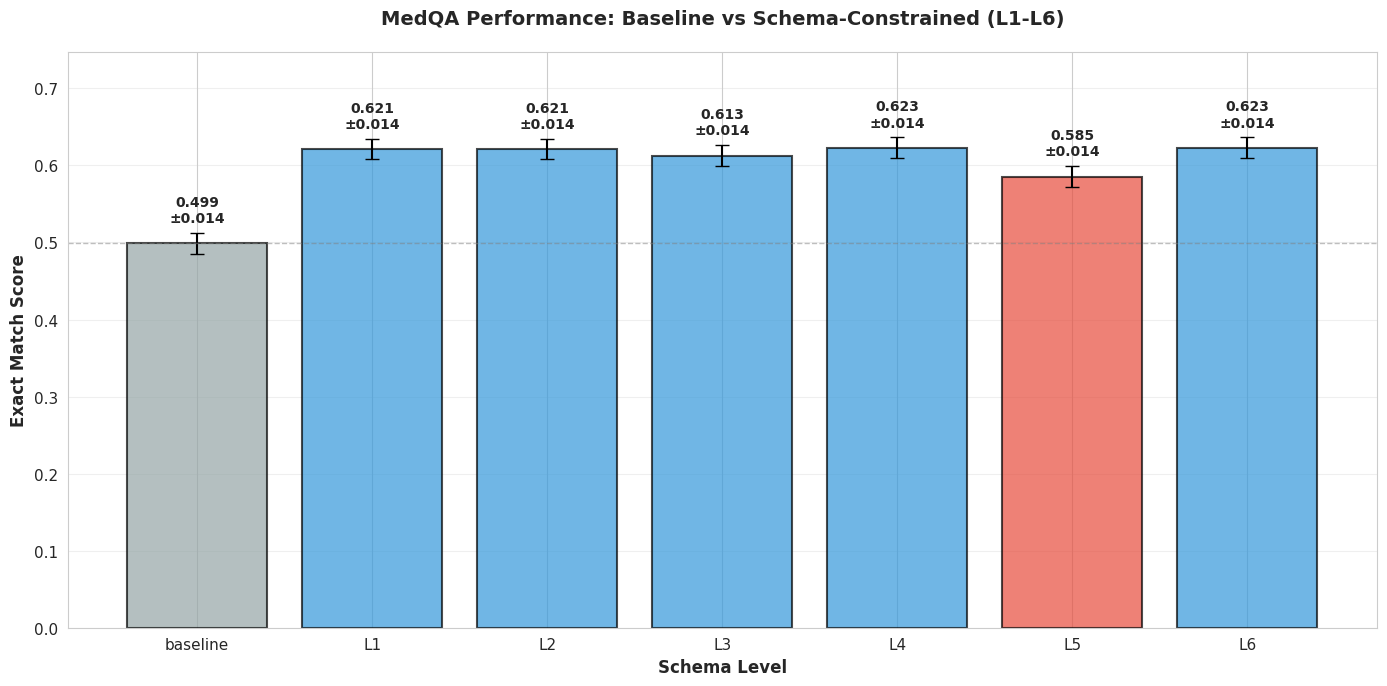

In [37]:
# 1. Performance comparison
fig, ax = plt.subplots(figsize=(14, 7))

levels = ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
scores = [performance_data.get(level, {}).get('exact_match', 0) for level in levels]
stderrs = [performance_data.get(level, {}).get('stderr', 0) for level in levels]

colors = ['#95a5a6' if level == 'baseline' else '#3498db' if level != 'L5' else '#e74c3c' 
          for level in levels]

x_pos = np.arange(len(levels))
bars = ax.bar(x_pos, scores, yerr=stderrs, capsize=5, color=colors, alpha=0.7, 
              edgecolor='black', linewidth=1.5)

for i, (bar, score, stderr) in enumerate(zip(bars, scores, stderrs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + stderr + 0.01,
            f'{score:.3f}\n±{stderr:.3f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

ax.set_ylabel('Exact Match Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_title('MedQA Performance: Baseline vs Schema-Constrained (L1-L6)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(levels, fontsize=11)
ax.set_ylim(0, max(scores) * 1.2)
ax.grid(alpha=0.3, axis='y')

if baseline_score > 0:
    ax.axhline(y=baseline_score, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


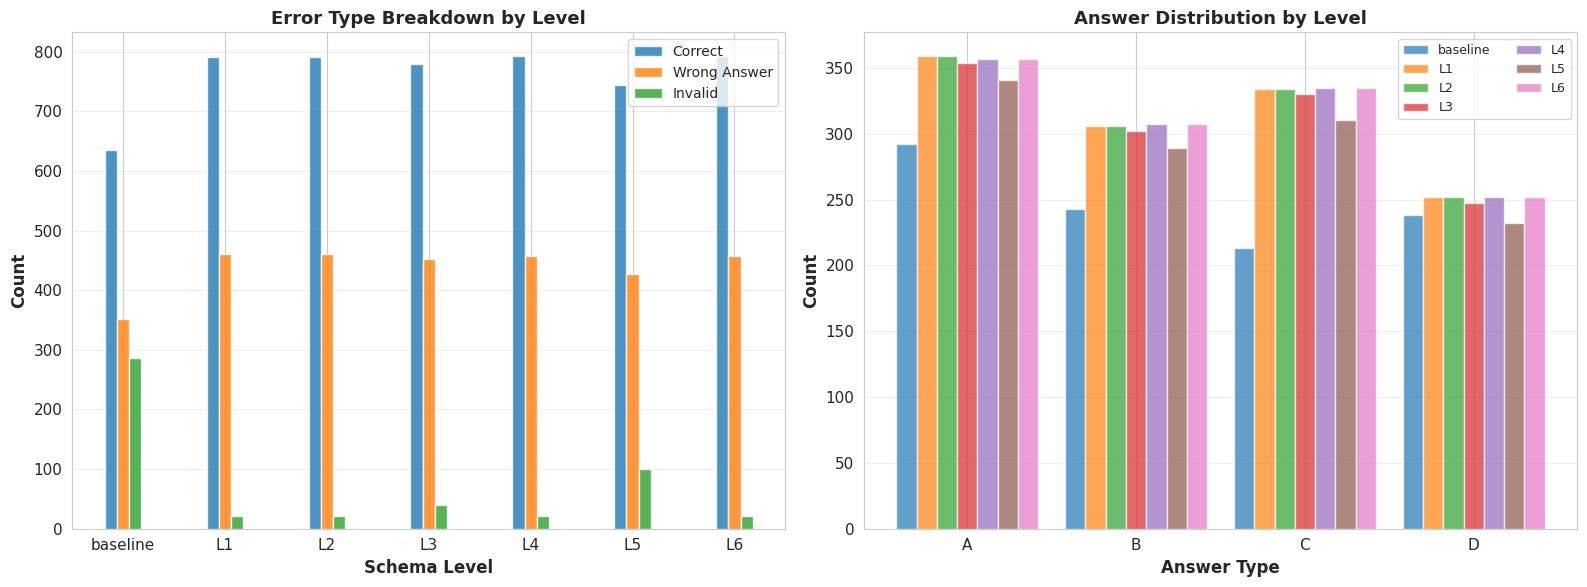

In [38]:
# 2. Error breakdown visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error types
ax1 = axes[0]
error_types = ['Correct', 'Wrong Answer', 'Invalid']
x = np.arange(len(levels))
width = 0.12

for i, err_type in enumerate(error_types):
    if err_type == 'Correct':
        values = [error_analysis.get(level, {}).get('correct', 0) for level in levels]
    elif err_type == 'Wrong Answer':
        values = [error_analysis.get(level, {}).get('wrong_answer', 0) for level in levels]
    else:
        values = [error_analysis.get(level, {}).get('invalid_answer', 0) for level in levels]
    
    offset = (i - 1) * width
    ax1.bar(x + offset, values, width, label=err_type, alpha=0.8)

ax1.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Error Type Breakdown by Level', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(levels)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')

# Answer distribution comparison
ax2 = axes[1]
x = np.arange(len(['A', 'B', 'C', 'D']))
width = 0.12

for i, level in enumerate(levels):
    if level in answer_distributions:
        dist = answer_distributions[level]
        values = [dist.get('A', 0), dist.get('B', 0), dist.get('C', 0), dist.get('D', 0)]
        offset = (i - 3) * width
        ax2.bar(x + offset, values, width, label=level, alpha=0.7)

ax2.set_xlabel('Answer Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Answer Distribution by Level', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['A', 'B', 'C', 'D'])
ax2.legend(fontsize=9, ncol=2)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'error_and_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


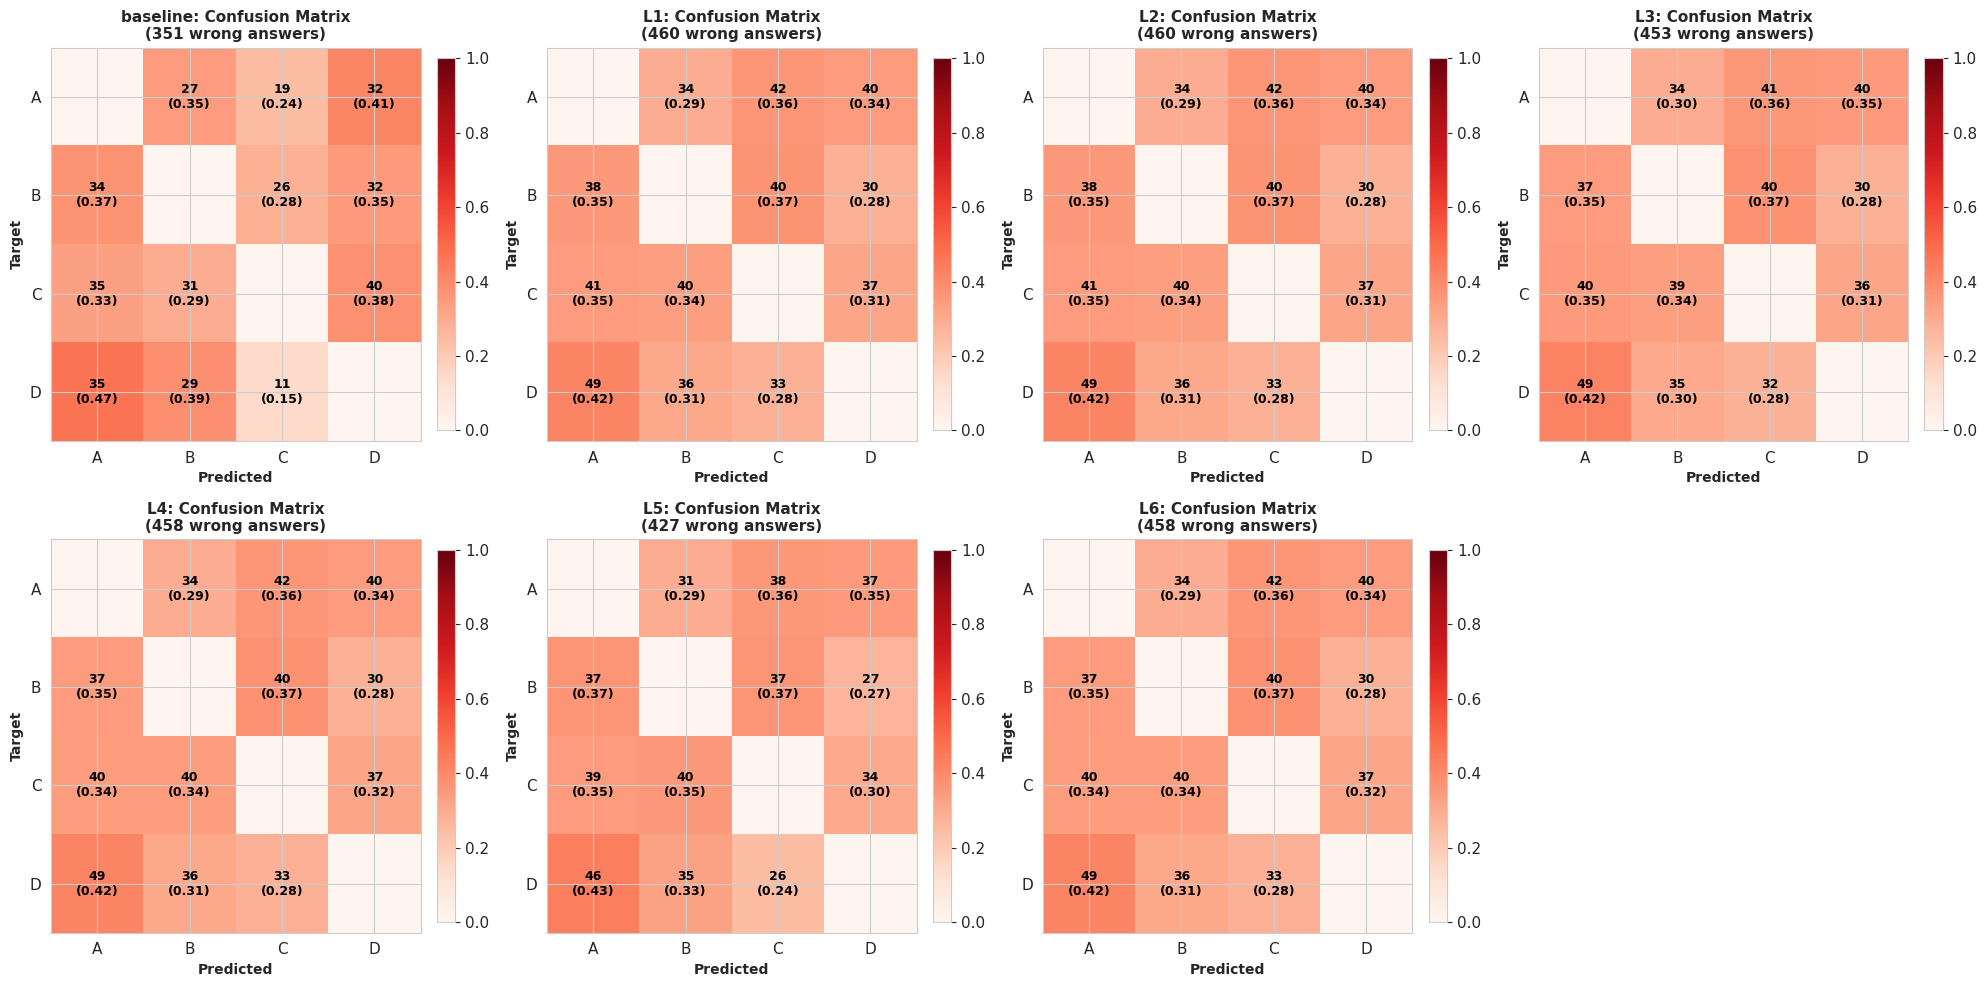

In [57]:
# 3. Confusion matrices heatmap for wrong answers
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, level in enumerate(['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']):
    if level not in error_analysis:
        continue
    
    ax = axes[idx]
    patterns = error_analysis[level]['wrong_patterns']
    
    if not patterns:
        ax.text(0.5, 0.5, 'No wrong answers', ha='center', va='center', fontsize=12)
        ax.set_title(f'{level}: Confusion Matrix', fontsize=12, fontweight='bold')
        ax.axis('off')
        continue
    
    # Build confusion matrix
    confusion_matrix = np.zeros((4, 4))
    answer_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    
    for target, predicted in patterns:
        if target in answer_map and predicted in answer_map:
            confusion_matrix[answer_map[target], answer_map[predicted]] += 1
    
    # Normalize by row (target)
    row_sums = confusion_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    confusion_matrix_norm = confusion_matrix / row_sums
    
    # Plot heatmap
    im = ax.imshow(confusion_matrix_norm, cmap='Reds', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(['A', 'B', 'C', 'D'])
    ax.set_yticklabels(['A', 'B', 'C', 'D'])
    ax.set_xlabel('Predicted', fontsize=10, fontweight='bold')
    ax.set_ylabel('Target', fontsize=10, fontweight='bold')
    ax.set_title(f'{level}: Confusion Matrix\n({len(patterns)} wrong answers)', 
                 fontsize=11, fontweight='bold')
    
    # Add text annotations
    for i in range(4):
        for j in range(4):
            if confusion_matrix[i, j] > 0:
                text = ax.text(j, i, f'{int(confusion_matrix[i, j])}\n({confusion_matrix_norm[i, j]:.2f})',
                             ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Hide unused subplots
for idx in range(7, 8):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


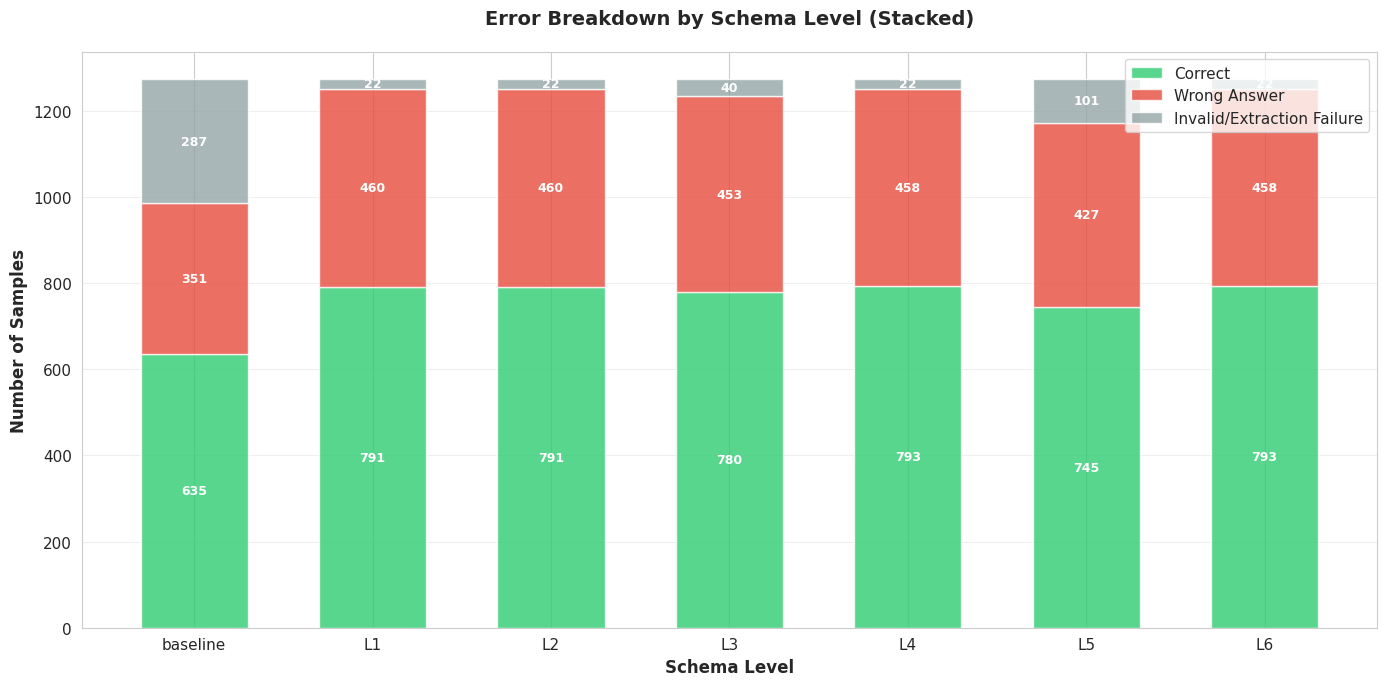

In [58]:
# 4. Error breakdown stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))

levels = ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
x = np.arange(len(levels))
width = 0.6

correct_counts = [error_analysis.get(level, {}).get('correct', 0) for level in levels]
wrong_counts = [error_analysis.get(level, {}).get('wrong_answer', 0) for level in levels]
invalid_counts = [error_analysis.get(level, {}).get('invalid_answer', 0) for level in levels]

p1 = ax.bar(x, correct_counts, width, label='Correct', color='#2ecc71', alpha=0.8)
p2 = ax.bar(x, wrong_counts, width, bottom=correct_counts, label='Wrong Answer', color='#e74c3c', alpha=0.8)
p3 = ax.bar(x, invalid_counts, width, bottom=np.array(correct_counts) + np.array(wrong_counts), 
            label='Invalid/Extraction Failure', color='#95a5a6', alpha=0.8)

# Add value labels on bars
for i, (c, w, inv) in enumerate(zip(correct_counts, wrong_counts, invalid_counts)):
    total = c + w + inv
    if c > 0:
        ax.text(i, c/2, f'{c}', ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    if w > 0:
        ax.text(i, c + w/2, f'{w}', ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    if inv > 0:
        ax.text(i, c + w + inv/2, f'{inv}', ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Error Breakdown by Schema Level (Stacked)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(levels, fontsize=11)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'error_breakdown_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


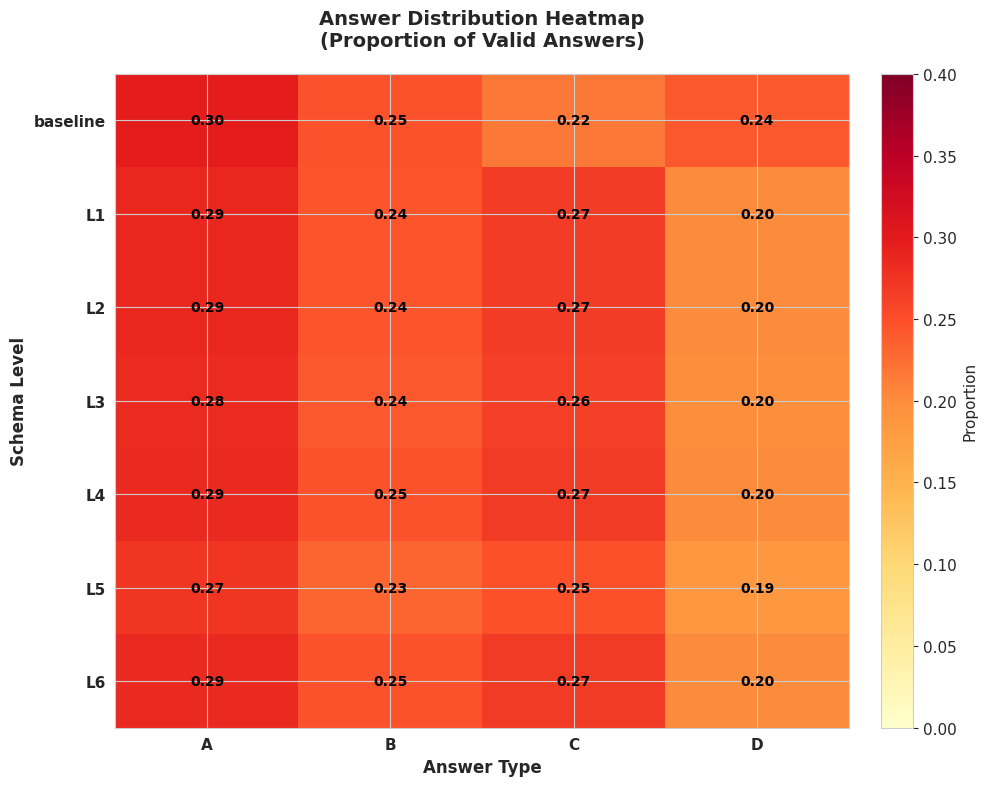

In [59]:
# 5. Answer distribution heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create matrix: rows = levels, columns = answer types
dist_matrix = []
for level in levels:
    if level in answer_distributions:
        dist = answer_distributions[level]
        total_valid = dist['total'] - dist['[invalid]']
        if total_valid > 0:
            row = [dist.get('A', 0)/total_valid, dist.get('B', 0)/total_valid, 
                   dist.get('C', 0)/total_valid, dist.get('D', 0)/total_valid]
        else:
            row = [0, 0, 0, 0]
    else:
        row = [0, 0, 0, 0]
    dist_matrix.append(row)

dist_matrix = np.array(dist_matrix)

im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.4)
ax.set_xticks(range(4))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(['A', 'B', 'C', 'D'], fontsize=11, fontweight='bold')
ax.set_yticklabels(levels, fontsize=11, fontweight='bold')
ax.set_xlabel('Answer Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_title('Answer Distribution Heatmap\n(Proportion of Valid Answers)', 
             fontsize=14, fontweight='bold', pad=20)

# Add text annotations
for i in range(len(levels)):
    for j in range(4):
        text = ax.text(j, i, f'{dist_matrix[i, j]:.2f}',
                     ha="center", va="center", color="black", fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, label='Proportion', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'answer_distribution_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


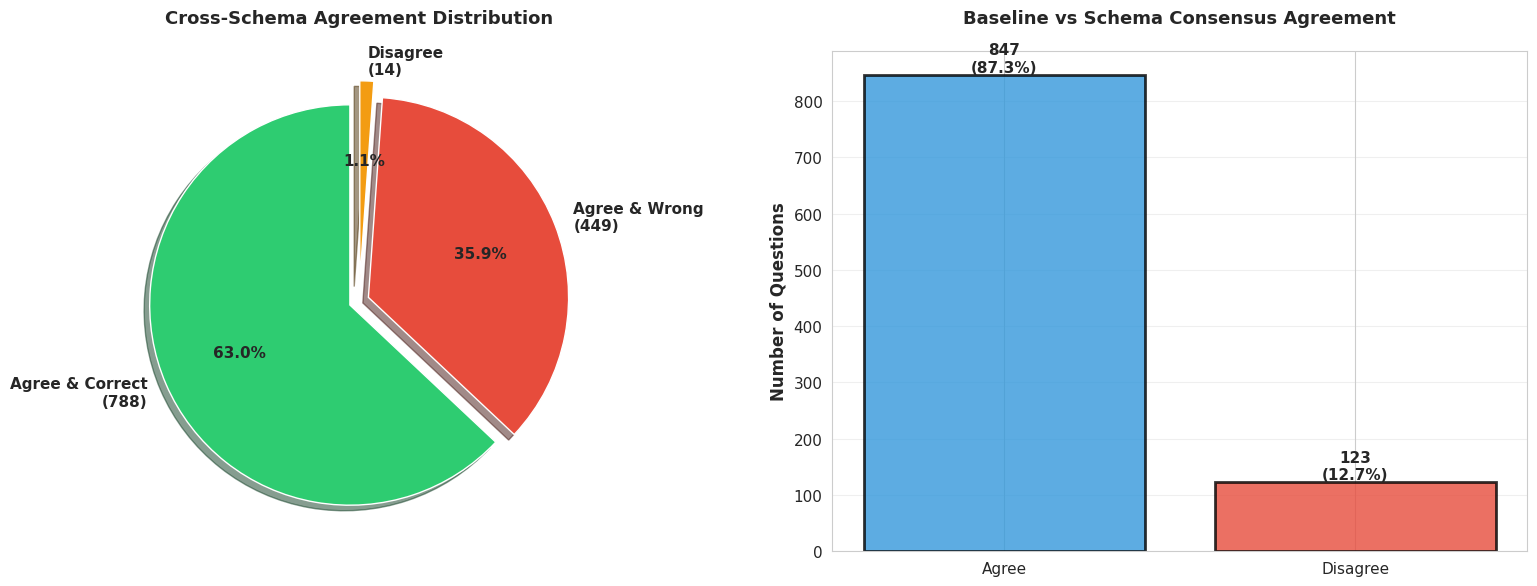

In [60]:
# 6. Cross-schema agreement visualization
if agreement_stats['total_questions'] > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie chart of agreement
    ax1 = axes[0]
    agree_correct = agreement_stats['schemas_agree_and_correct']
    agree_wrong = agreement_stats['schemas_agree_but_wrong']
    disagree = len(agreement_stats['disagreement_cases'])
    
    sizes = [agree_correct, agree_wrong, disagree]
    labels = [f'Agree & Correct\n({agree_correct})', 
              f'Agree & Wrong\n({agree_wrong})', 
              f'Disagree\n({disagree})']
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    explode = (0.05, 0.05, 0.1)
    
    ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax1.set_title('Cross-Schema Agreement Distribution', fontsize=13, fontweight='bold', pad=20)
    
    # Baseline vs Schema consensus
    ax2 = axes[1]
    if agreement_stats['baseline_vs_schema_agreement']:
        agree_count = agreement_stats['baseline_vs_schema_agreement']['agree']
        disagree_count = agreement_stats['baseline_vs_schema_agreement']['disagree']
        
        categories = ['Agree', 'Disagree']
        counts = [agree_count, disagree_count]
        colors_bar = ['#3498db', '#e74c3c']
        
        bars = ax2.bar(categories, counts, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
        ax2.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
        ax2.set_title('Baseline vs Schema Consensus Agreement', fontsize=13, fontweight='bold', pad=20)
        ax2.grid(alpha=0.3, axis='y')
        
        # Add value labels
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}\n({count/sum(counts)*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'cross_schema_agreement.png', dpi=300, bbox_inches='tight')
    plt.show()


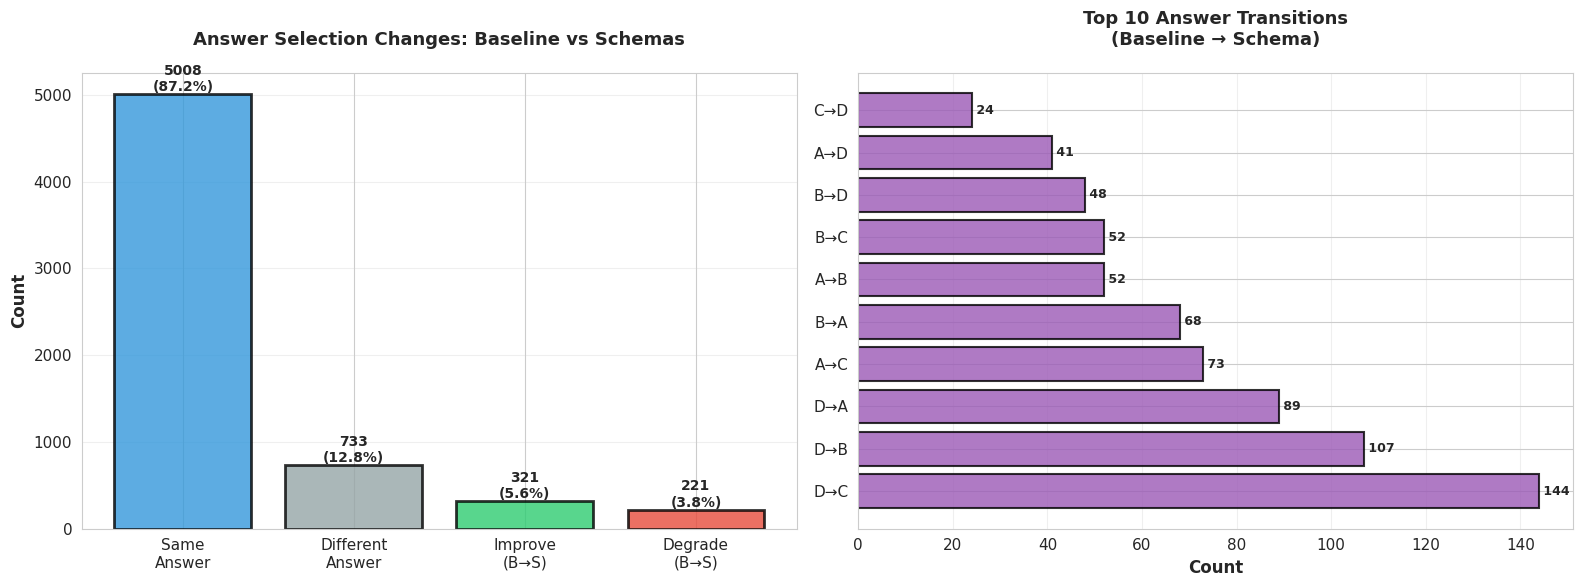

In [61]:
# 7. Answer change patterns: baseline to schema
if total_comparisons > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Answer change direction
    ax1 = axes[0]
    same = answer_changes['same_answer']
    diff = answer_changes['different_answer']
    improve = answer_changes['baseline_wrong_schema_correct']
    degrade = answer_changes['baseline_correct_schema_wrong']
    
    categories = ['Same\nAnswer', 'Different\nAnswer', 'Improve\n(B→S)', 'Degrade\n(B→S)']
    counts = [same, diff, improve, degrade]
    colors = ['#3498db', '#95a5a6', '#2ecc71', '#e74c3c']
    
    bars = ax1.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('Answer Selection Changes: Baseline vs Schemas', fontsize=13, fontweight='bold', pad=20)
    ax1.grid(alpha=0.3, axis='y')
    
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        pct = count / total_comparisons * 100
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Most common answer transitions
    ax2 = axes[1]
    if answer_changes['baseline_to_schema']:
        top_transitions = sorted(answer_changes['baseline_to_schema'].items(), 
                                key=lambda x: x[1], reverse=True)[:10]
        
        transitions = [f"{b}→{s}" for (b, s), _ in top_transitions]
        counts_trans = [count for _, count in top_transitions]
        
        bars = ax2.barh(transitions, counts_trans, color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=1.5)
        ax2.set_xlabel('Count', fontsize=12, fontweight='bold')
        ax2.set_title('Top 10 Answer Transitions\n(Baseline → Schema)', fontsize=13, fontweight='bold', pad=20)
        ax2.grid(alpha=0.3, axis='x')
        
        for bar, count in zip(bars, counts_trans):
            width = bar.get_width()
            ax2.text(width, bar.get_y() + bar.get_height()/2.,
                    f' {count}',
                    ha='left', va='center', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'answer_change_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()


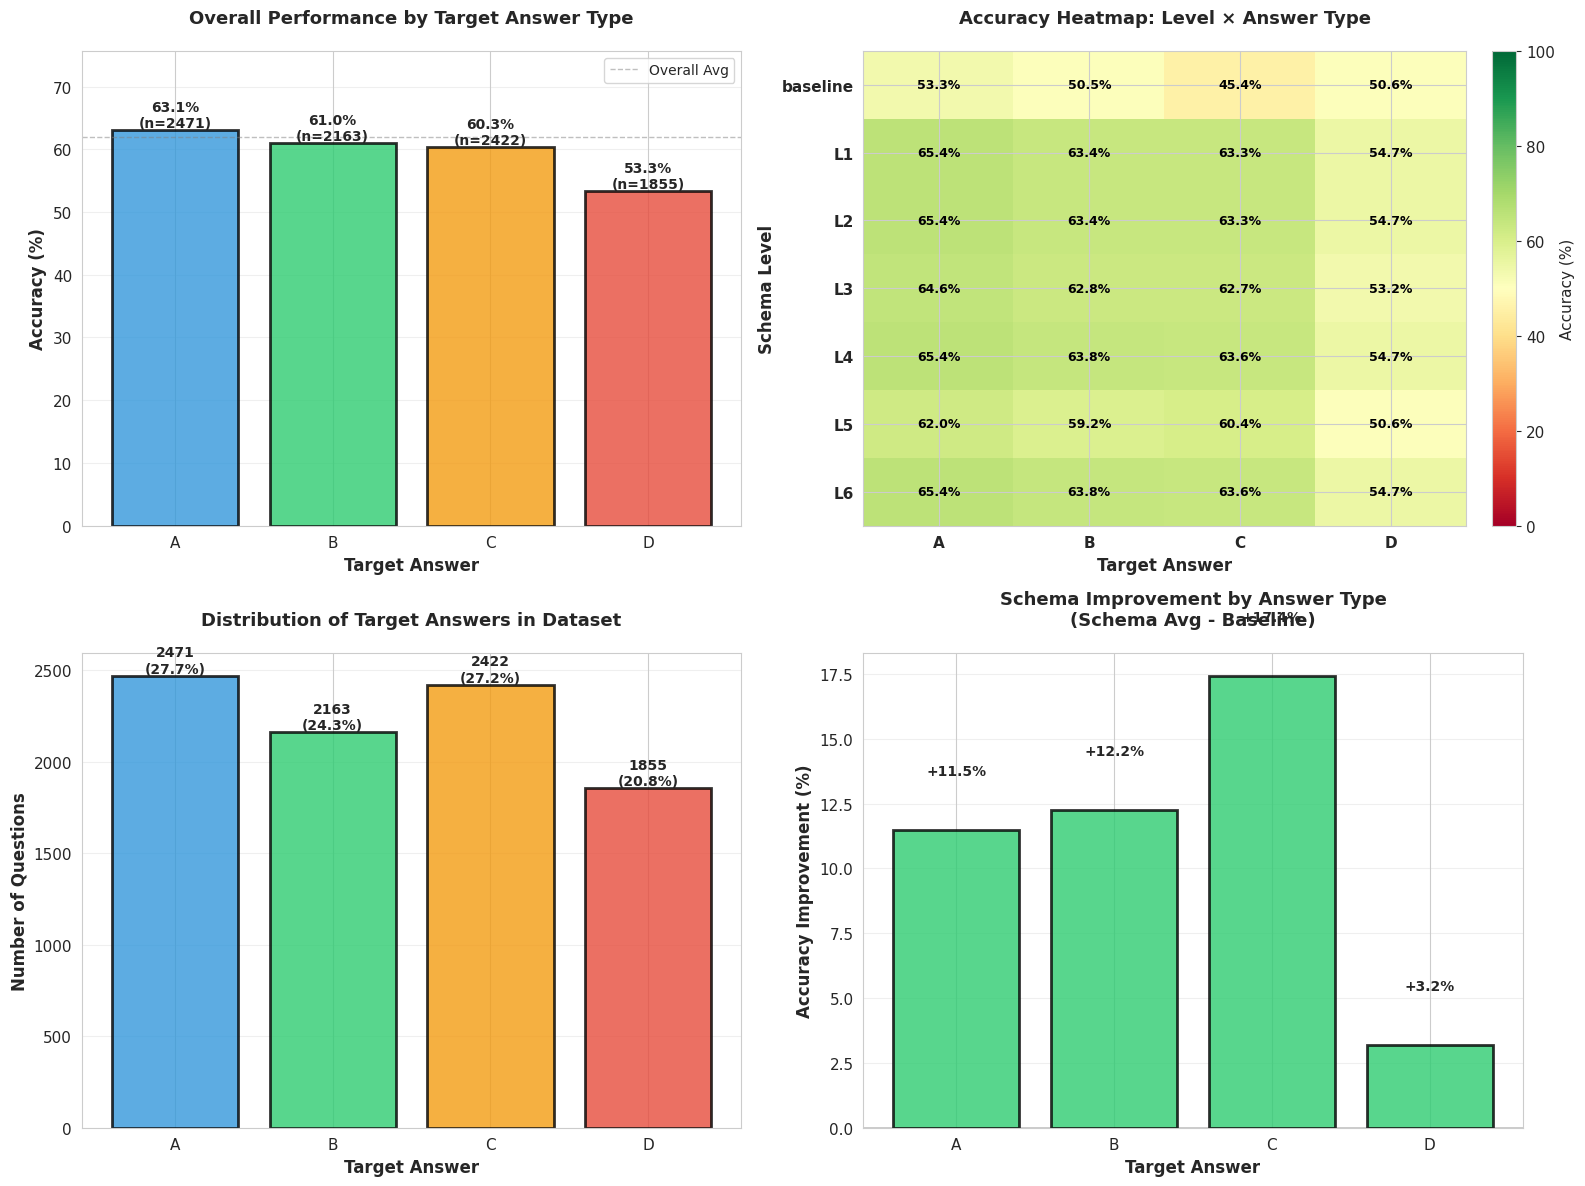

In [62]:
# 8. Performance by answer type (A, B, C, D)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall performance by target answer
ax1 = axes[0, 0]
targets = ['A', 'B', 'C', 'D']
accuracies = []
for target in targets:
    diff = target_difficulty[target]
    if diff['total'] > 0:
        acc = diff['correct'] / diff['total'] * 100
        accuracies.append(acc)
    else:
        accuracies.append(0)

bars = ax1.bar(targets, accuracies, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], 
               alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Target Answer', fontsize=12, fontweight='bold')
ax1.set_title('Overall Performance by Target Answer Type', fontsize=13, fontweight='bold', pad=20)
ax1.set_ylim(0, max(accuracies) * 1.2 if accuracies else 100)
ax1.grid(alpha=0.3, axis='y')
ax1.axhline(y=62, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Overall Avg')

for bar, acc, target in zip(bars, accuracies, targets):
    height = bar.get_height()
    total = target_difficulty[target]['total']
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%\n(n={total})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.legend(fontsize=10)

# Performance by level and answer type (heatmap)
ax2 = axes[0, 1]
perf_matrix = []
for level in levels:
    row = []
    for target in targets:
        if level in performance_by_target and target in performance_by_target[level]:
            perf = performance_by_target[level][target]
            if perf['total'] > 0:
                acc = perf['correct'] / perf['total'] * 100
            else:
                acc = 0
        else:
            acc = 0
        row.append(acc)
    perf_matrix.append(row)

perf_matrix = np.array(perf_matrix)
im = ax2.imshow(perf_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax2.set_xticks(range(4))
ax2.set_yticks(range(len(levels)))
ax2.set_xticklabels(targets, fontsize=11, fontweight='bold')
ax2.set_yticklabels(levels, fontsize=11, fontweight='bold')
ax2.set_xlabel('Target Answer', fontsize=12, fontweight='bold')
ax2.set_ylabel('Schema Level', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Heatmap: Level × Answer Type', fontsize=13, fontweight='bold', pad=20)

for i in range(len(levels)):
    for j in range(4):
        text = ax2.text(j, i, f'{perf_matrix[i, j]:.1f}%',
                     ha="center", va="center", color="black", fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax2, label='Accuracy (%)', fraction=0.046, pad=0.04)

# Distribution of target answers
ax3 = axes[1, 0]
target_counts = {target: target_difficulty[target]['total'] for target in targets}
bars = ax3.bar(target_counts.keys(), target_counts.values(), 
               color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], 
               alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
ax3.set_xlabel('Target Answer', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Target Answers in Dataset', fontsize=13, fontweight='bold', pad=20)
ax3.grid(alpha=0.3, axis='y')

total_q = sum(target_counts.values())
for bar, target in zip(bars, targets):
    height = bar.get_height()
    pct = height / total_q * 100
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Performance improvement by answer type
ax4 = axes[1, 1]
baseline_perf = {}
schema_perf = {}
for target in targets:
    if 'baseline' in performance_by_target and target in performance_by_target['baseline']:
        perf = performance_by_target['baseline'][target]
        if perf['total'] > 0:
            baseline_perf[target] = perf['correct'] / perf['total'] * 100
        else:
            baseline_perf[target] = 0
    else:
        baseline_perf[target] = 0
    
    # Average schema performance
    schema_accs = []
    for level in ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
        if level in performance_by_target and target in performance_by_target[level]:
            perf = performance_by_target[level][target]
            if perf['total'] > 0:
                schema_accs.append(perf['correct'] / perf['total'] * 100)
    schema_perf[target] = np.mean(schema_accs) if schema_accs else 0

improvements = [schema_perf[t] - baseline_perf[t] for t in targets]
colors_imp = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]

bars = ax4.bar(targets, improvements, color=colors_imp, alpha=0.8, edgecolor='black', linewidth=2)
ax4.set_ylabel('Accuracy Improvement (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Target Answer', fontsize=12, fontweight='bold')
ax4.set_title('Schema Improvement by Answer Type\n(Schema Avg - Baseline)', fontsize=13, fontweight='bold', pad=20)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.grid(alpha=0.3, axis='y')

for bar, imp, target in zip(bars, improvements, targets):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + (2 if height > 0 else -4),
            f'{imp:+.1f}%',
            ha='center', va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_by_answer_type.png', dpi=300, bbox_inches='tight')
plt.show()


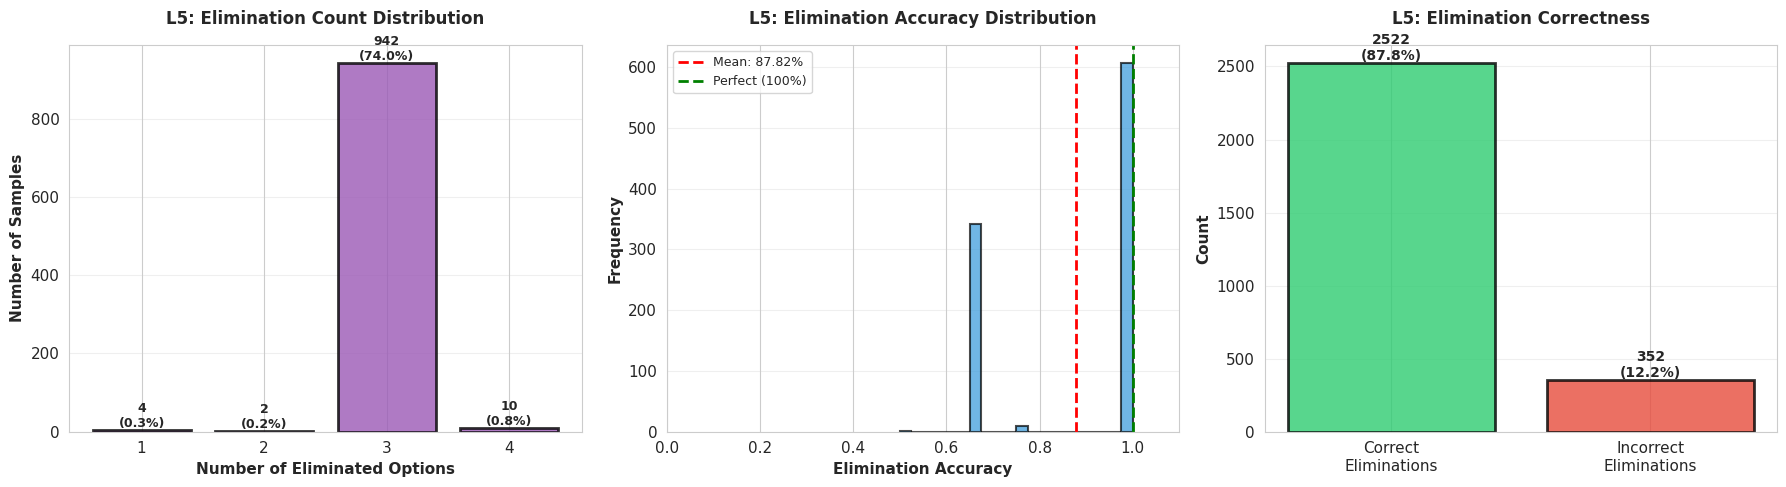

In [63]:
# 9. L5 Elimination Strategy Analysis Visualization
if 'L5' in parsed_samples and l5_elimination_analysis:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Elimination count distribution
    ax1 = axes[0]
    elim_counts = sorted(l5_elimination_analysis['elimination_count_dist'].items())
    counts = [c for c, _ in elim_counts]
    freqs = [f for _, f in elim_counts]
    
    bars = ax1.bar([str(c) for c in counts], freqs, color='#9b59b6', alpha=0.8, 
                   edgecolor='black', linewidth=2)
    ax1.set_xlabel('Number of Eliminated Options', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
    ax1.set_title('L5: Elimination Count Distribution', fontsize=12, fontweight='bold', pad=15)
    ax1.grid(alpha=0.3, axis='y')
    
    for bar, freq in zip(bars, freqs):
        height = bar.get_height()
        pct = freq / l5_elimination_analysis['total'] * 100
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{freq}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Elimination accuracy distribution
    ax2 = axes[1]
    if l5_elimination_analysis['elimination_accuracy']:
        accs = l5_elimination_analysis['elimination_accuracy']
        ax2.hist(accs, bins=20, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
        mean_acc = np.mean(accs)
        ax2.axvline(mean_acc, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_acc:.2%}')
        ax2.axvline(1.0, color='green', linestyle='--', linewidth=2, 
                   label='Perfect (100%)')
        ax2.set_xlabel('Elimination Accuracy', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('L5: Elimination Accuracy Distribution', fontsize=12, fontweight='bold', pad=15)
        ax2.legend(fontsize=9)
        ax2.grid(alpha=0.3, axis='y')
        ax2.set_xlim(0, 1.1)
    
    # Correct vs incorrect eliminations
    ax3 = axes[2]
    correct_elim = l5_elimination_analysis['correct_eliminations']
    incorrect_elim = l5_elimination_analysis['incorrect_eliminations']
    
    categories = ['Correct\nEliminations', 'Incorrect\nEliminations']
    counts_elim = [correct_elim, incorrect_elim]
    colors_elim = ['#2ecc71', '#e74c3c']
    
    bars = ax3.bar(categories, counts_elim, color=colors_elim, alpha=0.8, 
                   edgecolor='black', linewidth=2)
    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('L5: Elimination Correctness', fontsize=12, fontweight='bold', pad=15)
    ax3.grid(alpha=0.3, axis='y')
    
    total_elim = correct_elim + incorrect_elim
    for bar, count in zip(bars, counts_elim):
        height = bar.get_height()
        if total_elim > 0:
            pct = count / total_elim * 100
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'l5_elimination_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


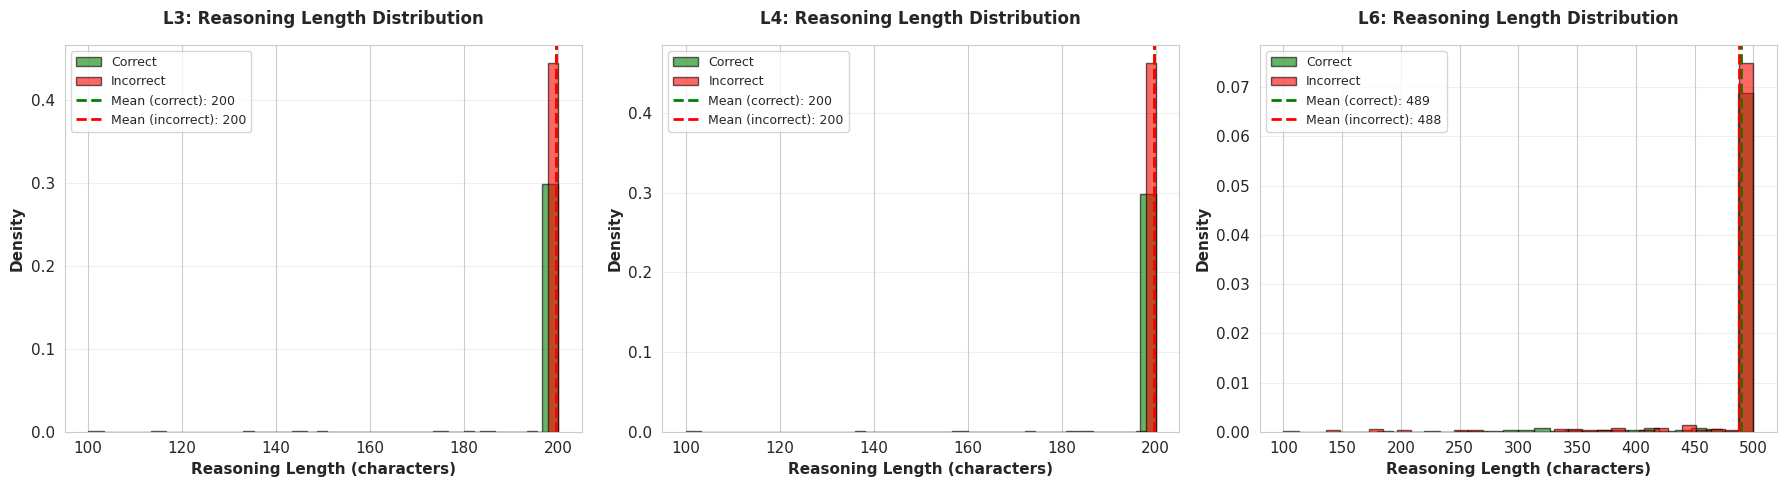

In [64]:
# 10. Reasoning length analysis
if reasoning_analysis:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, level in enumerate(['L3', 'L4', 'L6']):
        if level not in reasoning_analysis:
            continue
        
        ax = axes[idx]
        data = reasoning_analysis[level]
        
        correct_lengths = data['reasoning_lengths_correct']
        incorrect_lengths = data['reasoning_lengths_incorrect']
        
        if correct_lengths and incorrect_lengths:
            ax.hist(correct_lengths, bins=30, alpha=0.6, label='Correct', 
                   color='green', density=True, edgecolor='black', linewidth=1)
            ax.hist(incorrect_lengths, bins=30, alpha=0.6, label='Incorrect', 
                   color='red', density=True, edgecolor='black', linewidth=1)
            
            if correct_lengths:
                ax.axvline(np.mean(correct_lengths), color='green', linestyle='--', 
                          linewidth=2, label=f'Mean (correct): {np.mean(correct_lengths):.0f}')
            if incorrect_lengths:
                ax.axvline(np.mean(incorrect_lengths), color='red', linestyle='--', 
                          linewidth=2, label=f'Mean (incorrect): {np.mean(incorrect_lengths):.0f}')
            
            ax.set_xlabel('Reasoning Length (characters)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Density', fontsize=11, fontweight='bold')
            ax.set_title(f'{level}: Reasoning Length Distribution', fontsize=12, fontweight='bold', pad=15)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'reasoning_length_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


## 12. Key Insights & Interpretations


In [39]:
print("="*80)
print("KEY INSIGHTS & INTERPRETATIONS")
print("="*80)

print("\n1. SCHEMA CONSTRAINTS SIGNIFICANTLY IMPROVE PERFORMANCE")
print("-"*80)
baseline_score = performance_data.get('baseline', {}).get('exact_match', 0)
best_schema_score = max([performance_data.get(level, {}).get('exact_match', 0) 
                         for level in ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']])
improvement = best_schema_score - baseline_score
improvement_pct = (improvement / baseline_score * 100) if baseline_score > 0 else 0
print(f"   • Baseline: {baseline_score:.4f} ({baseline_score*100:.2f}%)")
print(f"   • Best schema: {best_schema_score:.4f} ({best_schema_score*100:.2f}%)")
print(f"   • Improvement: +{improvement:.4f} (+{improvement_pct:.1f}%)")
print(f"   • Key insight: Schema constraints provide ~{improvement_pct:.0f}% performance boost")
print(f"     primarily by reducing extraction failures and ensuring valid answer format.")

print("\n2. WHY SCHEMAS HELP: Error Reduction Analysis")
print("-"*80)
baseline_errors = error_analysis.get('baseline', {})
baseline_invalid = baseline_errors.get('invalid_answer', 0)
baseline_total = baseline_errors.get('total', 1)

best_schema = 'L4' if 'L4' in error_analysis else 'L1'
schema_errors = error_analysis.get(best_schema, {})
schema_invalid = schema_errors.get('invalid_answer', 0)
schema_total = schema_errors.get('total', 1)

print(f"   • Baseline invalid answers: {baseline_invalid}/{baseline_total} ({baseline_invalid/baseline_total*100:.2f}%)")
print(f"   • {best_schema} invalid answers: {schema_invalid}/{schema_total} ({schema_invalid/schema_total*100:.2f}%)")
print(f"   • Reduction in invalid answers: {baseline_invalid - schema_invalid} ({(baseline_invalid/baseline_total - schema_invalid/schema_total)*100:.1f} percentage points)")
print(f"   • Mechanism: Structured JSON output eliminates parsing ambiguity,")
print(f"     enum constraints ensure valid format, and schema validation catches errors early.")

print("\n3. ANSWER SELECTION CHANGES")
print("-"*80)
if total_comparisons > 0:
    same_pct = answer_changes['same_answer'] / total_comparisons * 100
    diff_pct = answer_changes['different_answer'] / total_comparisons * 100
    print(f"   • Same answer (baseline = schema): {same_pct:.1f}%")
    print(f"   • Different answer: {diff_pct:.1f}%")
    if answer_changes['different_answer'] > 0:
        improvement_rate = answer_changes['baseline_wrong_schema_correct'] / answer_changes['different_answer'] * 100
        degradation_rate = answer_changes['baseline_correct_schema_wrong'] / answer_changes['different_answer'] * 100
        print(f"   • When different: {improvement_rate:.1f}% improve, {degradation_rate:.1f}% degrade")
        print(f"   • Insight: Schemas not only improve extraction but also change answer selection")
        print(f"     in a way that's more often correct than incorrect.")

print("\n4. CONFIDENCE CALIBRATION")
print("-"*80)
for level in ['L2', 'L4', 'L6']:
    if level not in confidence_analysis:
        continue
    data = confidence_analysis[level]
    print(f"   • {level}:")
    print(f"     - ECE: {data['ece']:.4f} ({'well-calibrated' if data['ece'] < 0.1 else 'poorly-calibrated'})")
    print(f"     - Correlation: {data['correlation']:.4f} ({'strong' if data['correlation'] > 0.3 else 'moderate' if data['correlation'] > 0.1 else 'weak'})")
    print(f"     - Confidence gap (correct - incorrect): {data['mean_confidence_correct'] - data['mean_confidence_incorrect']:+.3f}")
    if data['high_conf_accuracy'] and data['high_conf_accuracy'] > 0.7:
        print(f"     - High confidence (≥0.8) accuracy: {data['high_conf_accuracy']:.2%} → Can be used for filtering")
    print()

print("\n5. L5 UNDERPERFORMANCE: Root Cause Analysis")
print("-"*80)
l5_score = performance_data.get('L5', {}).get('exact_match', 0)
avg_other = np.mean([performance_data.get(level, {}).get('exact_match', 0) 
                     for level in ['L1', 'L2', 'L3', 'L4', 'L6']])
l5_gap = l5_score - avg_other

if 'L5' in parsed_samples and l5_elimination_analysis:
    elim_acc = np.mean(l5_elimination_analysis['elimination_accuracy']) if l5_elimination_analysis['elimination_accuracy'] else None
    print(f"   • L5 performance: {l5_score:.4f} vs average others: {avg_other:.4f} (gap: {l5_gap:+.4f})")
    if elim_acc:
        print(f"   • Elimination accuracy: {elim_acc:.2%} (expected: 100%)")
        print(f"   • Gap: {100 - elim_acc*100:.1f} percentage points")
        print(f"   • Root cause: Model struggles with complex nested structure (eliminated array)")
        print(f"     and often eliminates correct options or fails to generate exactly 3 eliminations.")
        print(f"     This leads to schema validation failures even when the answer might be correct.")

print("\n6. CROSS-SCHEMA CONSISTENCY")
print("-"*80)
if agreement_stats['total_questions'] > 0:
    agree_pct = agreement_stats['all_agree'] / agreement_stats['total_questions'] * 100
    print(f"   • Schema agreement rate: {agree_pct:.1f}%")
    print(f"   • When schemas agree: {agreement_stats['schemas_agree_and_correct']/agreement_stats['all_agree']*100:.1f}% are correct")
    print(f"   • Insight: High agreement suggests schemas are consistent in their answer selection.")
    if len(agreement_stats['disagreement_cases']) > 0:
        print(f"   • Disagreement cases: {len(agreement_stats['disagreement_cases'])} - these are harder questions")

print("\n7. RECOMMENDATIONS")
print("-"*80)
print("   • For maximum performance: Use L1, L2, L4, or L6 (avoid L5)")
print("   • For calibration analysis: Use L2, L4, or L6 (include confidence)")
print("   • For reasoning extraction: Use L3, L4, or L6")
print("   • Confidence scores show moderate calibration: Can be used for uncertainty")
print("     estimation but should be interpreted with caution")
print("   • Schemas improve performance through:")
print("     - Reduced extraction failures (structured output)")
print("     - Better answer selection (constraints guide reasoning)")
print("     - Early error detection (schema validation)")
print("   • L5 underperforms due to complexity: Consider simplifying the schema")

print("\n" + "="*80)


KEY INSIGHTS & INTERPRETATIONS

1. SCHEMA CONSTRAINTS SIGNIFICANTLY IMPROVE PERFORMANCE
--------------------------------------------------------------------------------
   • Baseline: 0.4988 (49.88%)
   • Best schema: 0.6229 (62.29%)
   • Improvement: +0.1241 (+24.9%)
   • Key insight: Schema constraints provide ~25% performance boost
     primarily by reducing extraction failures and ensuring valid answer format.

2. WHY SCHEMAS HELP: Error Reduction Analysis
--------------------------------------------------------------------------------
   • Baseline invalid answers: 287/1273 (22.55%)
   • L4 invalid answers: 22/1273 (1.73%)
   • Reduction in invalid answers: 265 (20.8 percentage points)
   • Mechanism: Structured JSON output eliminates parsing ambiguity,
     enum constraints ensure valid format, and schema validation catches errors early.

3. ANSWER SELECTION CHANGES
--------------------------------------------------------------------------------
   • Same answer (baseline = schem